# Load libraries

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps  # Ensure this is imported
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from PyALE import ale
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress, spearmanr

/home/anding/miniconda3/envs/dsl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
chamau_lag = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
chamau_daily = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
oensingen_1_lag = pd.read_csv("../datasets/Oensingen_2018-19_clean_newlag.csv")
oensingen_1_daily = pd.read_csv("../datasets/Oensingen_Daily_2018-19_clean_newlag.csv")
oensingen_2_lag = pd.read_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_2_daily = pd.read_csv("../datasets/Oensingen_Daily_2021-23_clean_newlag.csv")
aeschi_lag = pd.read_csv("../datasets/Aeschi_2019-20_clean_newlag.csv")
aeschi_daily = pd.read_csv("../datasets/Aeschi_Daily_2019-20_newlag.csv")
forel_lag = pd.read_csv("../datasets/Forel_2024-25_clean_newlag.csv")
forel_daily = pd.read_csv("../datasets/Forel_Daily_2024-25_clean_newlag.csv")
tanikon_lag = pd.read_csv("../datasets/Tanikon_2023-25_clean_newlag.csv")
tanikon_daily = pd.read_csv("../datasets/Tanikon_Daily_2023-25_clean_newlag.csv")

# SHAP Analysis for XGBoost Models

This notebook performs SHAP (SHapley Additive exPlanations) analysis on XGBoost models trained on each dataset to understand feature importance and interactions.

# Define Helper Functions

In [3]:
# Define predictor sets (same as in XGBoost_experiments.ipynb)

base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", 
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "Fertilizer_N_kg_ha"
]

hourly_lag_predictors = [
    # Base variables
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", 
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # Lag features
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # Management
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation",

    "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

hourly_augmented_predictors = hourly_lag_predictors + [
    # Rolling means
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # Rolling sums
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
]

daily_lag_predictors = [
    # Base variables
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm",
    "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # Lag features (daily suffix instead of _daily)
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # Management
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation",

    "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

daily_augmented_predictors = daily_lag_predictors + [
    # Rolling means
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # Rolling sums
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
]

print("Predictor sets defined successfully!")

Predictor sets defined successfully!


In [4]:
def train_xgb_timeseries_with_shap(df, predictors, target, test_size=0.1, hyperparams=None, random_state=42, plot=True):
    """
    Train XGBoost on time-series data using chronological split with SHAP analysis.
    
    Parameters:
    -----------
    df : DataFrame - Input data
    predictors : list - Feature column names
    target : str - Target column name
    test_size : float - Fraction of data for testing (default 0.1)
    hyperparams : dict - XGBoost hyperparameters (if None, uses defaults)
    random_state : int - Random seed
    plot : bool - Whether to generate plots
    
    IMPORTANT: predictors must match the actual columns in df exactly.
    """
    
    # EXTRACT FEATURES/TARGET (no filtering - must match exactly like XGBoost_experiments)
    X = df[predictors]
    y = df[target]
    
    # HANDLE NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # OFFSET FOR POSITIVITY
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # CHRONOLOGICAL SPLIT
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # Store test dates for time series plot
    # For hourly data: index is Timestamp
    # For daily data: index is integer, need to get Date column
    try:
        # Check if index has .date attribute (datetime index)
        _ = X_test.index.date
        test_dates = X_test.index
        is_datetime_index = True
    except AttributeError:
        # Daily data - get dates from Date column
        if 'Date' in df.columns:
            test_dates = df.loc[X_test.index, 'Date']
        else:
            test_dates = X_test.index  # Fallback to integer index
        is_datetime_index = False
    
    # Get time ranges for printing
    if is_datetime_index:
        time_train = (df.index.min(), df.index[:split_idx].max())
        time_test = (df.index[split_idx], df.index.max())
    else:
        if 'Date' in df.columns:
            train_indices = X_train.index
            test_indices = X_test.index
            time_train = (df.loc[train_indices, 'Date'].min(), df.loc[train_indices, 'Date'].max())
            time_test = (df.loc[test_indices, 'Date'].min(), df.loc[test_indices, 'Date'].max())
        else:
            time_train = (df.index.min(), df.index[:split_idx].max())
            time_test = (df.index[split_idx], df.index.max())
    
    print(f"Train period: {time_train[0]} → {time_train[1]}")
    print(f"Test  period: {time_test[0]} → {time_test[1]}")
    
    # DATA LEAKAGE CHECK
    try:
        train_dates_set = set(X_train.index.date)
        test_dates_set = set(X_test.index.date)
    except AttributeError:
        train_indices = X_train.index
        test_indices = X_test.index
        
        if 'Date' in df.columns:
            train_dates_set = set(pd.to_datetime(df.loc[train_indices, 'Date']).dt.date)
            test_dates_set = set(pd.to_datetime(df.loc[test_indices, 'Date']).dt.date)
        else:
            train_dates_set = set()
            test_dates_set = set()
            print("  ⚠️  Cannot check for data leakage (no Date column found)")
    
    overlap_dates = train_dates_set & test_dates_set
    if len(overlap_dates) > 0:
        print(f"  ⚠️  DATA LEAKAGE WARNING: {len(overlap_dates)} dates appear in BOTH train and test!")
    else:
        print(f"  ✅ No data leakage detected")
    
    # DEFAULT HYPERPARAMETERS (matching XGBoost_experiments.ipynb)
    default_params = {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 1,
        'gamma': 0,
        'random_state': random_state,
        'n_jobs': -1
    }
    
    # Merge with provided hyperparams (provided params override defaults)
    if hyperparams is not None:
        model_params = {**default_params, **hyperparams}
        print(f"\nUsing custom hyperparameters: {hyperparams}")
    else:
        model_params = default_params
        print("\nUsing default hyperparameters")
    
    # Ensure n_jobs and random_state are set
    model_params['n_jobs'] = -1
    if 'random_state' not in model_params:
        model_params['random_state'] = random_state
    
    # TRAIN MODEL
    model = XGBRegressor(**model_params)
    model.fit(X_train, y_train, verbose=False)
    
    # PREDICTIONS
    y_pred = model.predict(X_test)
    
    # REVERT OFFSET
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    # EVALUATION
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    # FEATURE IMPORTANCE - use predictors list like XGBoost_experiments
    importances = pd.Series(model.feature_importances_, index=predictors).sort_values(ascending=False)
    
    print("\nModel evaluation:")
    print(f"  R² (linear scale): {r2:.3f}")
    print(f"  Spearman ρ:        {rho:.3f}")
    
    # ========== SHAP ANALYSIS ==========
    print("\nComputing SHAP values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # PLOT
    if plot:
        # Create 3-subplot figure: scatter, feature importance, and TIME SERIES
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Scatter plot
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"XGBoost (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # 2. Feature importance
        top_features = importances.head(15)
        axes[1].barh(range(len(top_features)), top_features.values)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel("Importance (Gain)")
        axes[1].set_title("Top 15 Features")
        axes[1].invert_yaxis()
        
        # 3. TIME SERIES COMPARISON (now uses correct dates for daily data)
        axes[2].plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5)
        axes[2].plot(test_dates, y_pred_lin, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("N₂O Flux")
        axes[2].set_title("Time Series Comparison")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
        
        # ========== WIDER TIME SERIES WITH MANAGEMENT EVENTS ==========
        # Define management columns and their colors
        management_events = {
            'Mowing': {'color': 'green', 'label': 'Mowing'},
            'FertilizerOrganic': {'color': 'brown', 'label': 'Organic Fertilizer'},
            'FertilizerMineral': {'color': 'blue', 'label': 'Mineral Fertilizer'},
            'SoilCultivation': {'color': 'orange', 'label': 'Soil Cultivation'},
            'Grazing': {'color': 'purple', 'label': 'Grazing'},
        }
        
        # Get management data for test period
        test_df = df.loc[X_test.index].copy()
        
        fig2, ax2 = plt.subplots(figsize=(16, 6))
        
        # Plot observed and predicted
        ax2.plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5, zorder=5)
        ax2.plot(test_dates, y_pred_lin, label="Predicted", color="royalblue", lw=1.5, alpha=0.8, zorder=5)
        
        # Add management events as vertical lines
        for mgmt_col, props in management_events.items():
            if mgmt_col in test_df.columns:
                # Find where management event occurred (value > 0)
                event_mask = test_df[mgmt_col] > 0
                if event_mask.any():
                    if is_datetime_index:
                        event_dates = test_df.index[event_mask]
                    else:
                        event_dates = test_df.loc[event_mask, 'Date'] if 'Date' in test_df.columns else test_df.index[event_mask]
                    
                    # Get unique dates for events
                    if hasattr(event_dates, 'dt'):
                        unique_dates = event_dates.dt.date.unique()
                    elif hasattr(event_dates, 'date'):
                        unique_dates = pd.Series([d.date() for d in event_dates]).unique()
                    else:
                        unique_dates = event_dates.unique()
                    
                    # Plot vertical lines for each unique event date
                    for i, date in enumerate(unique_dates):
                        ax2.axvline(x=pd.Timestamp(date), color=props['color'], linestyle='--', 
                                   alpha=0.7, lw=1.5, label=props['label'] if i == 0 else "", zorder=1)
        
        ax2.set_xlabel("Date", fontsize=12)
        ax2.set_ylabel("N₂O Flux", fontsize=12)
        ax2.set_title("Time Series with Management Events (XGBoost)", fontsize=14, fontweight='bold')
        ax2.legend(loc='upper left', fontsize=10)
        ax2.grid(True, alpha=0.3, zorder=0)
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # ========== SHAP PLOTS ==========
        # SHAP Bar Plot
        # Mean absolute SHAP importance
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        
        # Signed mean SHAP — shows direction
        mean_signed_shap = shap_values.mean(axis=0)
        
        df = pd.DataFrame({
            "feature": X_test.columns,
            "mean_abs_SHAP": mean_abs_shap,
            "mean_signed_SHAP": mean_signed_shap
        }).sort_values("mean_abs_SHAP", ascending=False).head(10)

        df = df.sort_values("mean_abs_SHAP", ascending=True)
        
        plt.figure(figsize=(12,8))
        colors = df["mean_signed_SHAP"].apply(lambda x: "red" if x > 0 else "blue")
        
        plt.barh(df["feature"], df["mean_abs_SHAP"], color=colors)
        plt.title("Directional SHAP Feature Importance (Global)", fontsize=14)
        plt.xlabel("Mean |SHAP| Value (Impact on N₂O Emissions)")
        plt.tight_layout()
        plt.show()
        
        # SHAP Beeswarm Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, show=False, max_display=15)
        plt.title("SHAP Feature Effects", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "explainer": explainer,
        "shap_values": shap_values,
        "r2": r2,
        "spearman_rho": rho,
        "feature_importance": importances,
        "y_test": y_test_lin,
        "y_pred": y_pred_lin,
        "X_test": X_test,
        "test_dates": test_dates,
    }

# Dataset 1: Chamau

In [5]:
# Prepare Chamau data (using .copy() to avoid modifying original dataframes)
# IMPORTANT: Match XGBoost_experiments.ipynb EXACTLY for data preparation
chamau_lag_df = chamau_lag.copy()
chamau_lag_df['Timestamp'] = pd.to_datetime(chamau_lag_df['Timestamp'])
chamau_lag_df = chamau_lag_df.set_index('Timestamp').sort_index()


# LOG FERT VALUES
chamau_lag_df["Fertilizer_N_kg_ha_log"] = np.log1p(chamau_lag_df["Fertilizer_N_kg_ha"])

lag_decay_cols = [c for c in chamau_lag_df.columns if c.startswith('Fertilizer_N_kg_ha_exp')]

for col in lag_decay_cols:
    chamau_lag_df[col + "_log"] = np.log1p(chamau_lag_df[col])  # log(1+x)
    
# For daily: XGBoost_experiments does NOT set Date as index, just sorts by it
chamau_daily_df = chamau_daily.copy()
chamau_daily_df['Date'] = pd.to_datetime(chamau_daily_df['Date'])
chamau_daily_df = chamau_daily_df.sort_values('Date')  # NOT set_index - matches XGBoost_experiments exactly

# LOG FERT VALUES
chamau_daily_df["Fertilizer_N_kg_ha_log"] = np.log1p(chamau_daily_df["Fertilizer_N_kg_ha"])

decay_cols = [c for c in chamau_daily_df.columns if c.startswith('Fertilizer_N_kg_ha_exp')]

for col in decay_cols:
    chamau_daily_df[col + "_log"] = np.log1p(chamau_daily_df[col])  # log(1+x) for stability


# Define CHAMAU-SPECIFIC predictors (matching XGBoost_experiments.ipynb exactly)
# Both hourly and daily datasets use the same _daily suffix for lag features
chamau_base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",

    "Fertilizer_N_kg_ha"
]

chamau_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation",

    "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

chamau_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_4cm_roll3d_mean", "SoilTemp_4cm_roll5d_mean", "SoilTemp_4cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_4cm_roll3d_sum", "SoilTemp_4cm_roll5d_sum", "SoilTemp_4cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation",

    "Fertilizer_N_kg_ha", "Fertilizer_N_kg_ha_expHL3d", "Fertilizer_N_kg_ha_expHL7d", "Fertilizer_N_kg_ha_expHL14d"
]

# Load best performing hyperparameters for Chamau
with open("xgboost_params/Chamau/best_performing_hyperparameters.json", "r") as f:
    chamau_hyperparams = json.load(f)

print("Chamau data and predictors prepared successfully!")
print(f"Loaded hyperparameters for {len(chamau_hyperparams)} experiment settings")

Chamau data and predictors prepared successfully!
Loaded hyperparameters for 6 experiment settings


## Chamau - Hourly Base Model

CHAMAU - HOURLY BASE MODEL
Train period: 2014-01-01 08:15:00 → 2021-07-31 12:15:00
Test  period: 2021-07-31 13:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0.1, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.6}

Model evaluation:
  R² (linear scale): 0.228
  Spearman ρ:        0.455

Computing SHAP values...


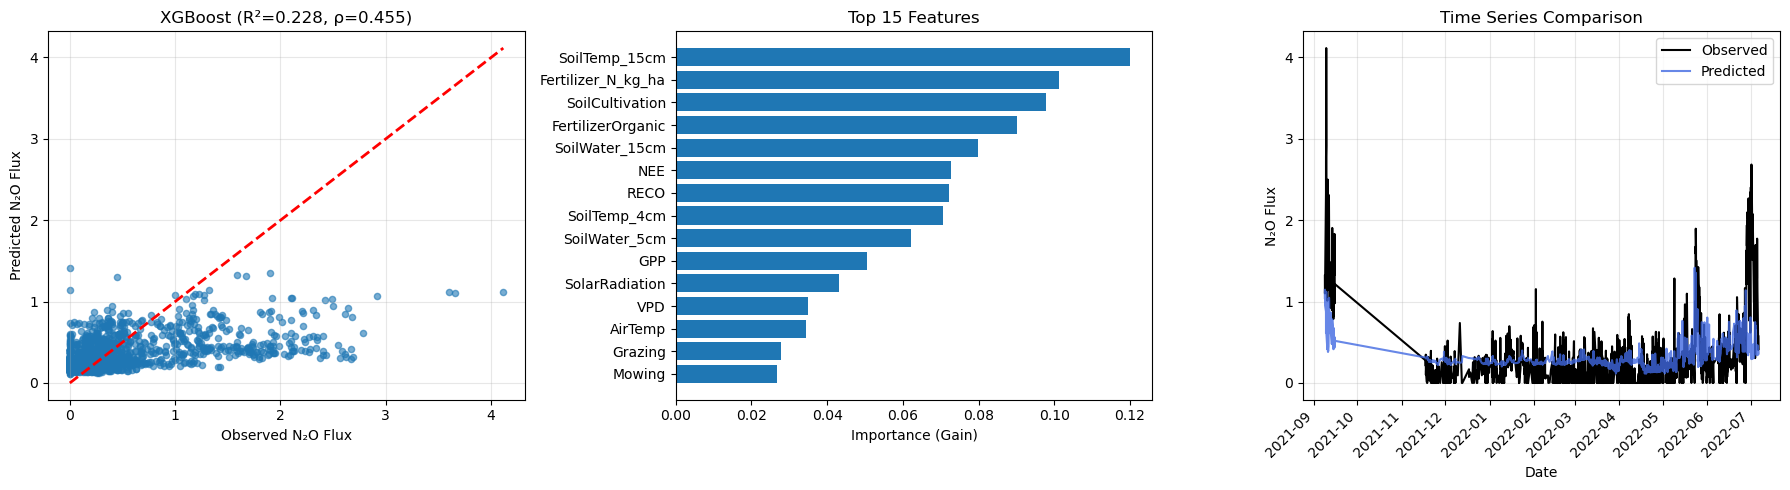

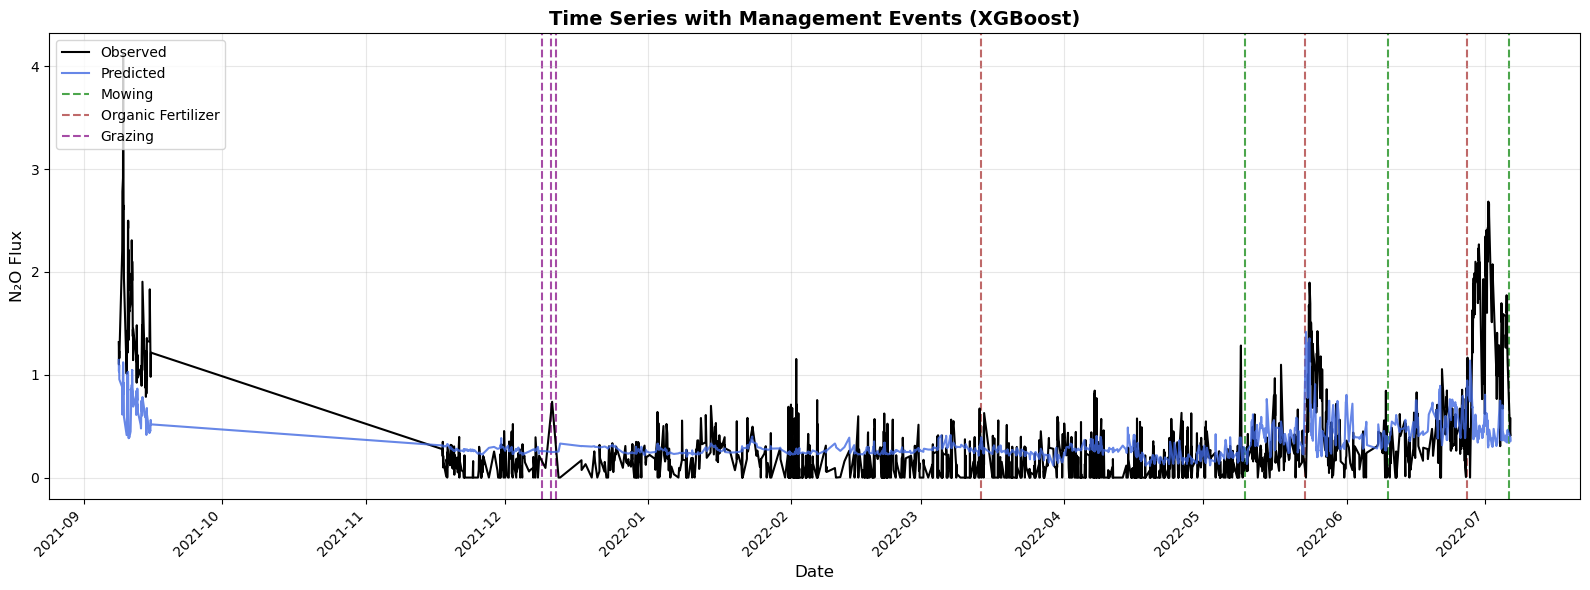

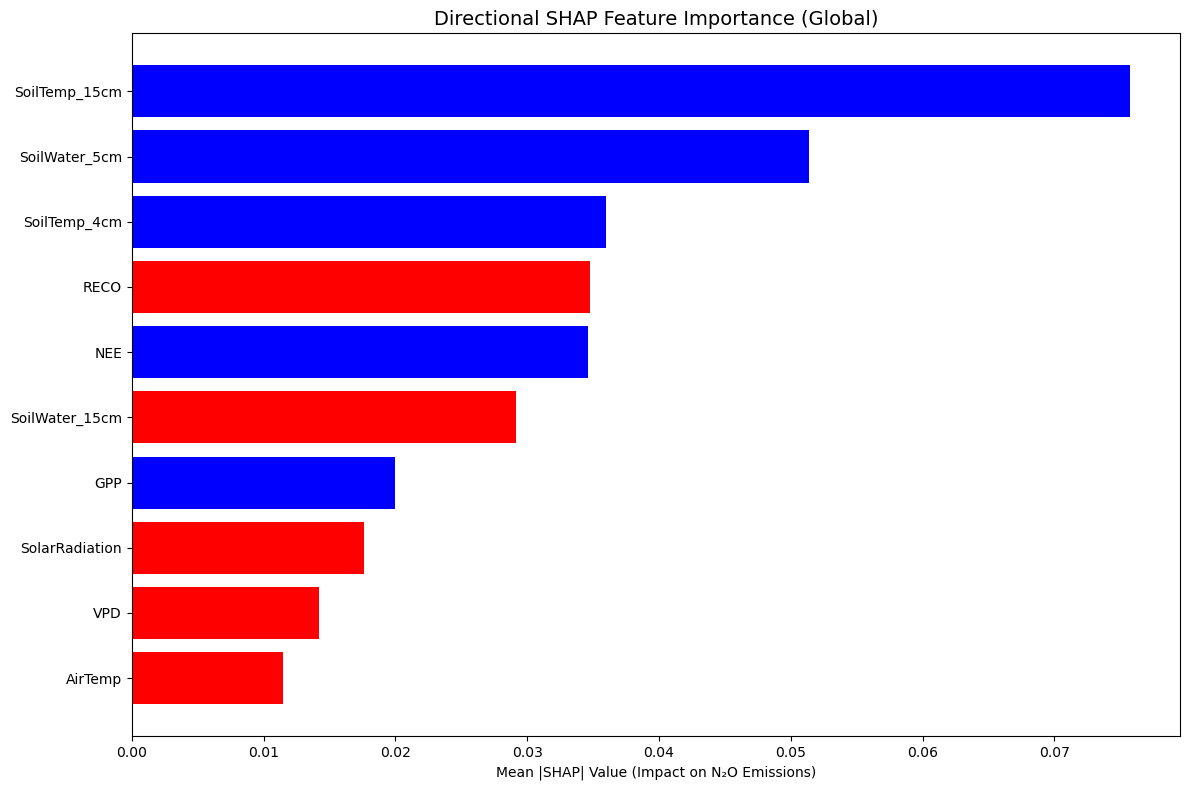

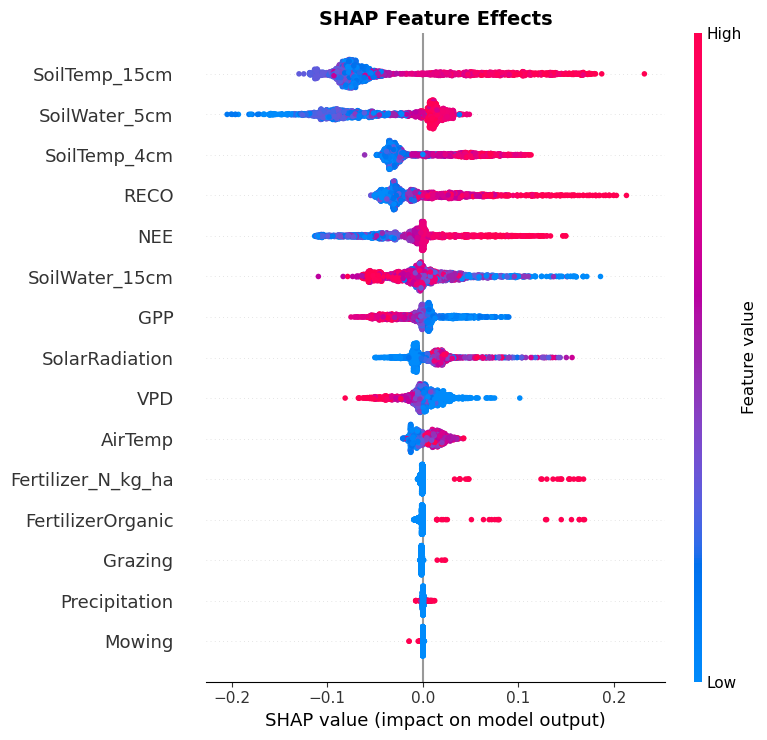

In [6]:
print("="*80)
print("CHAMAU - HOURLY BASE MODEL")
print("="*80)

chamau_hourly_base = train_xgb_timeseries_with_shap(
    df=chamau_lag_df,
    predictors=chamau_base_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_hyperparams['Hourly_Base']
)

## Chamau - Hourly Lag Model

CHAMAU - HOURLY LAG MODEL
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.7}

Model evaluation:
  R² (linear scale): 0.318
  Spearman ρ:        0.560

Computing SHAP values...


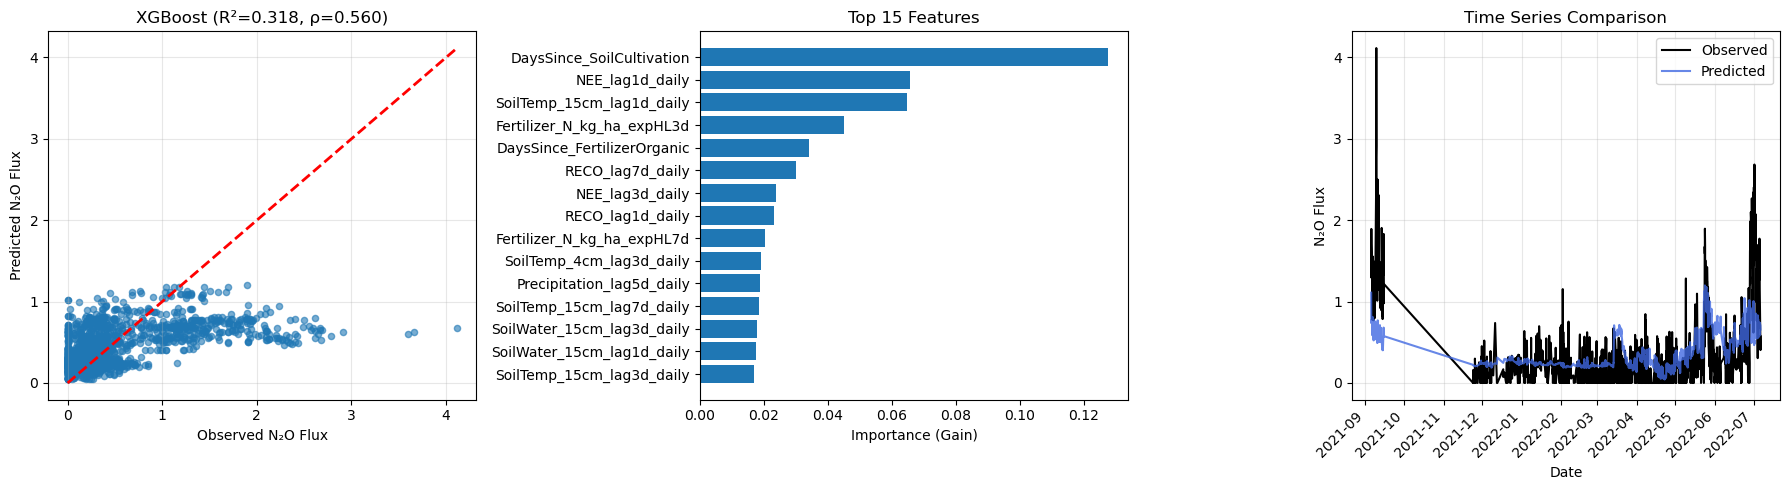

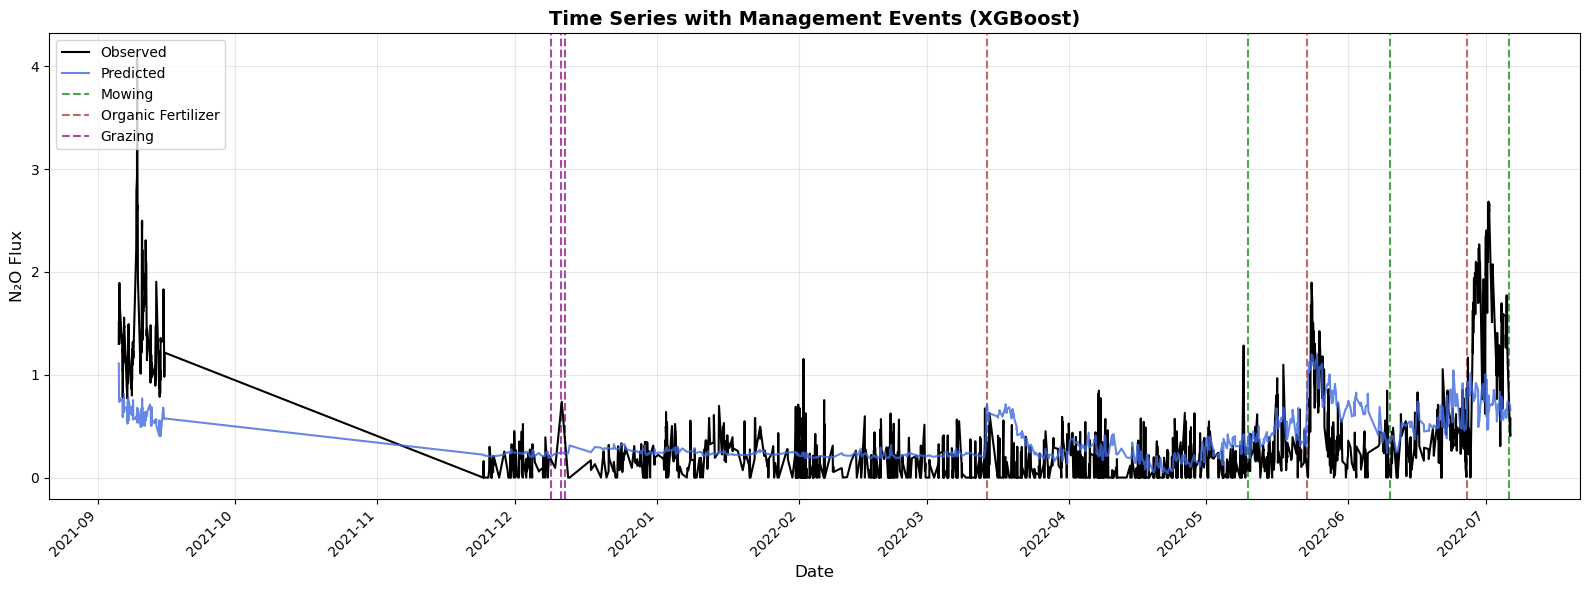

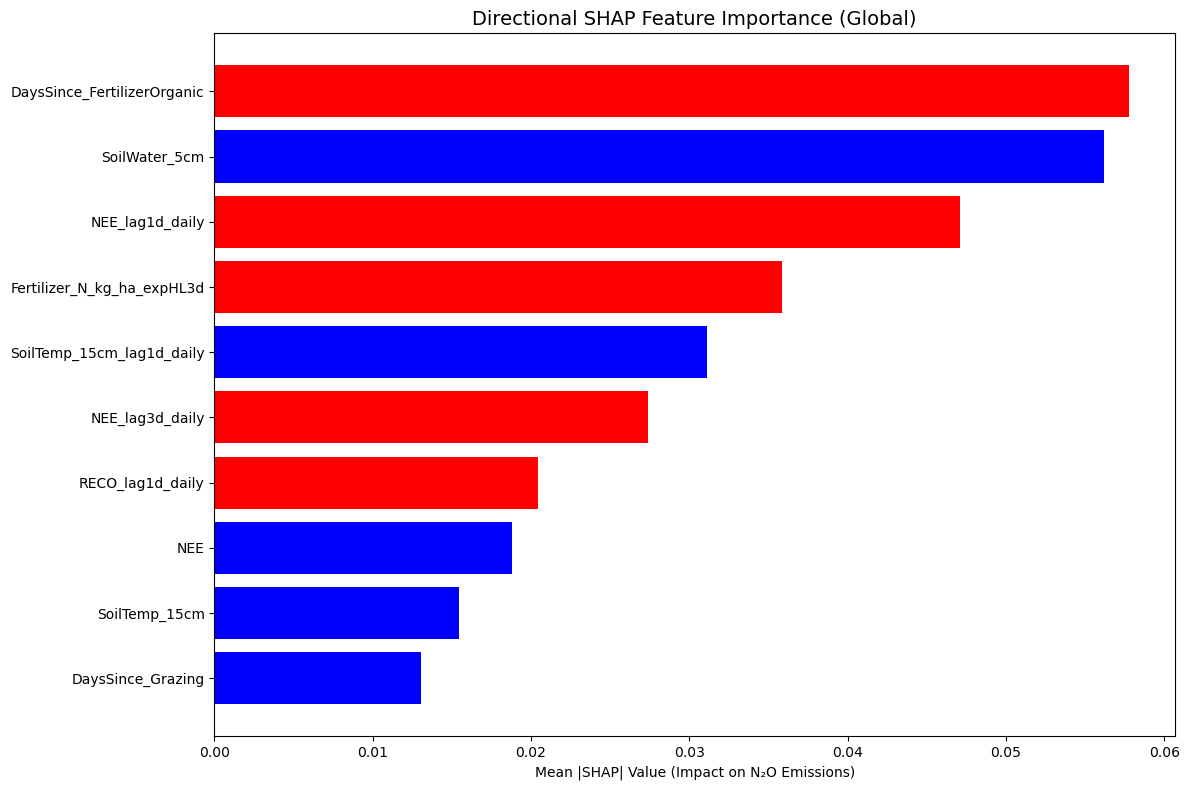

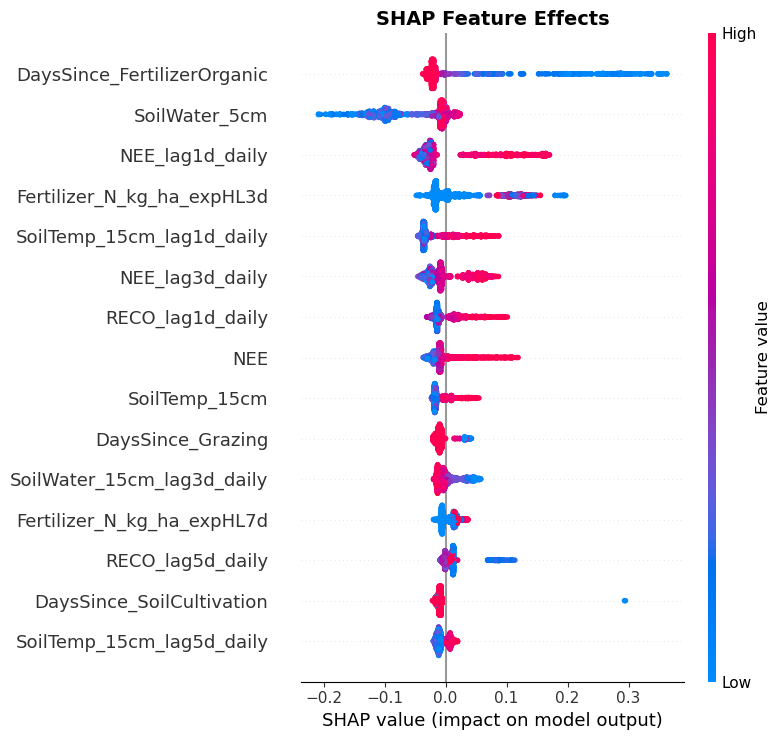

In [7]:
print("="*80)
print("CHAMAU - HOURLY LAG MODEL")
print("="*80)

chamau_hourly_lag = train_xgb_timeseries_with_shap(
    df=chamau_lag_df,
    predictors=chamau_lag_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_hyperparams['Hourly_Lag']
)

## Chamau - Hourly Augmented Model

CHAMAU - HOURLY AUGMENTED MODEL
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.6}

Model evaluation:
  R² (linear scale): 0.292
  Spearman ρ:        0.544

Computing SHAP values...


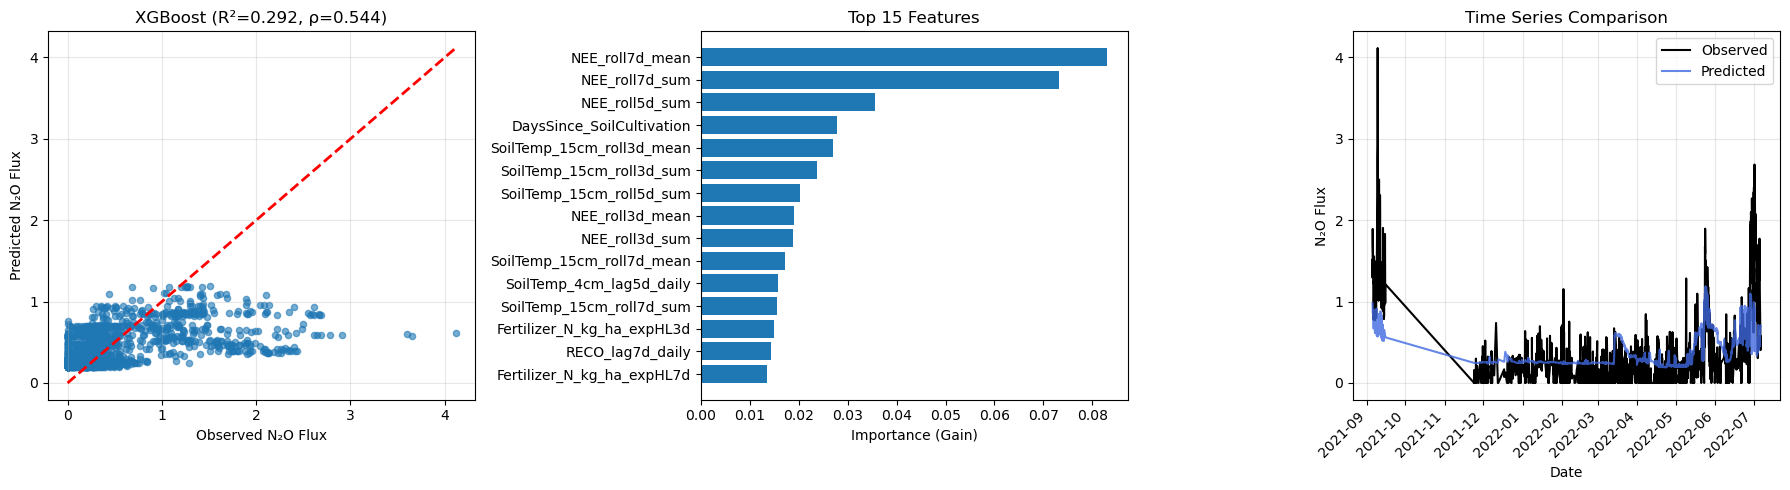

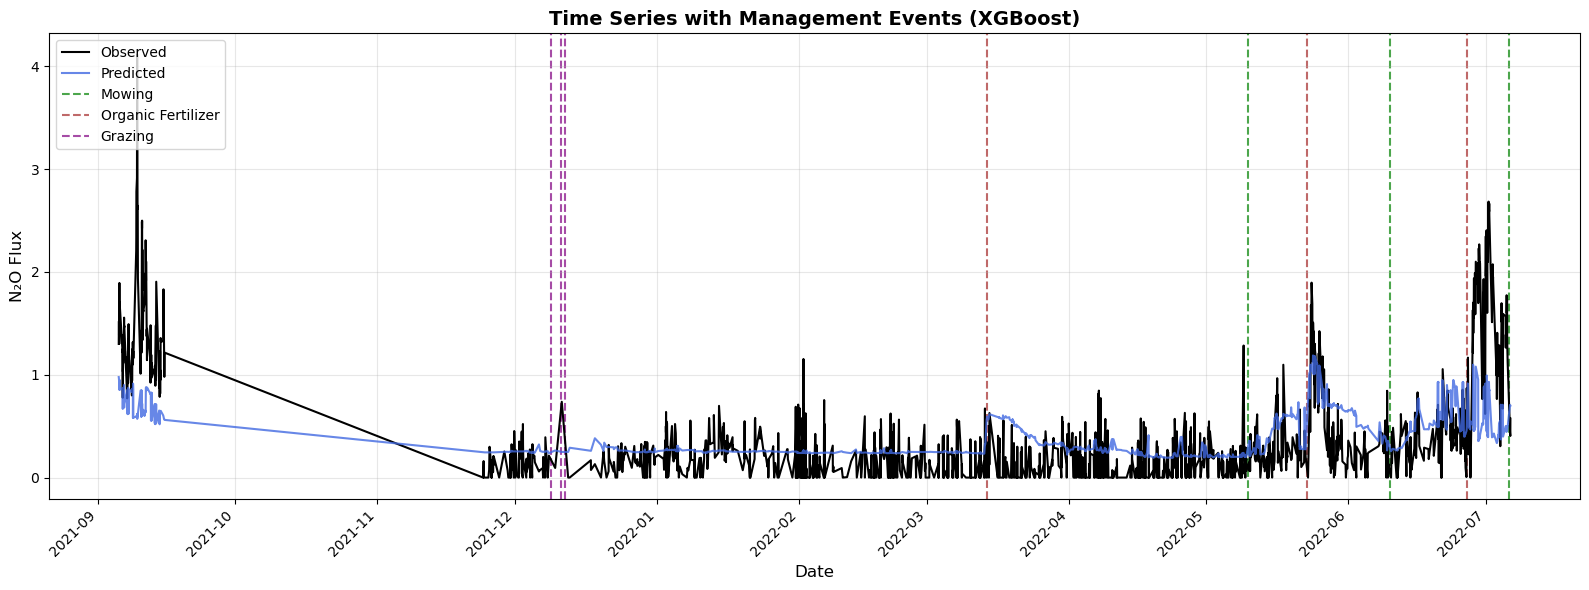

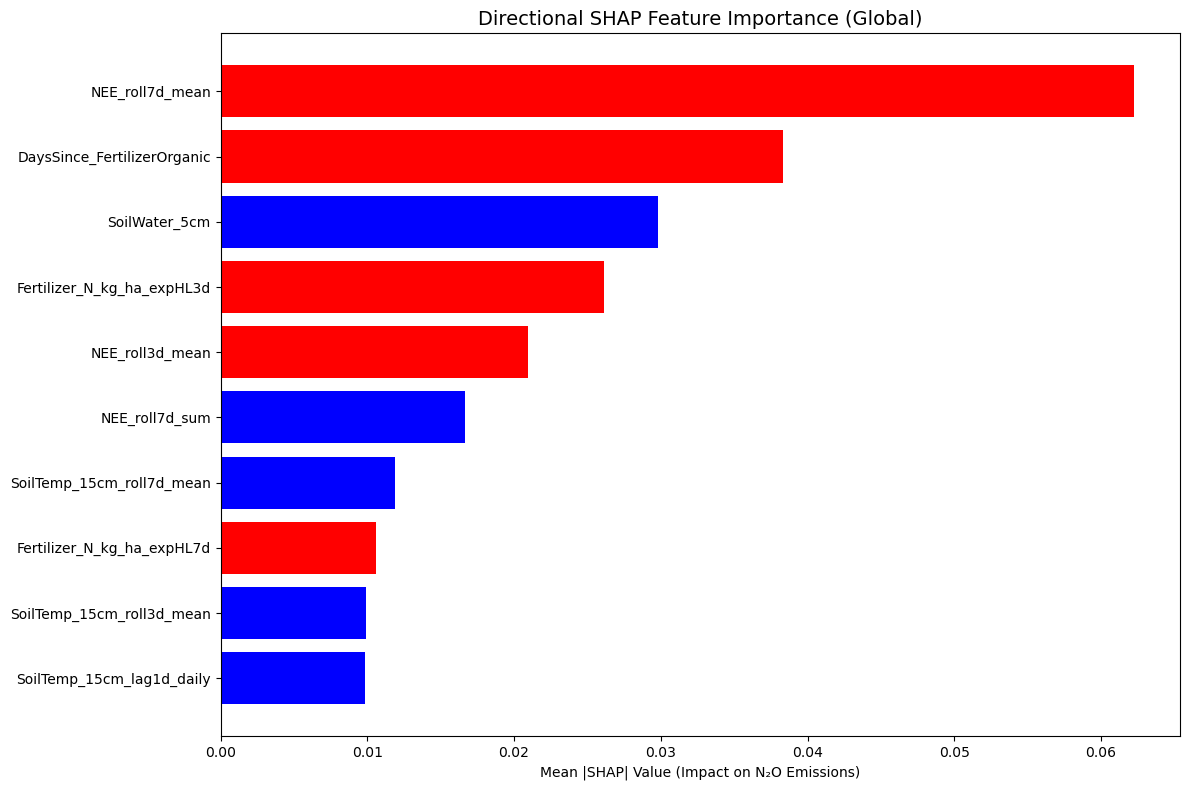

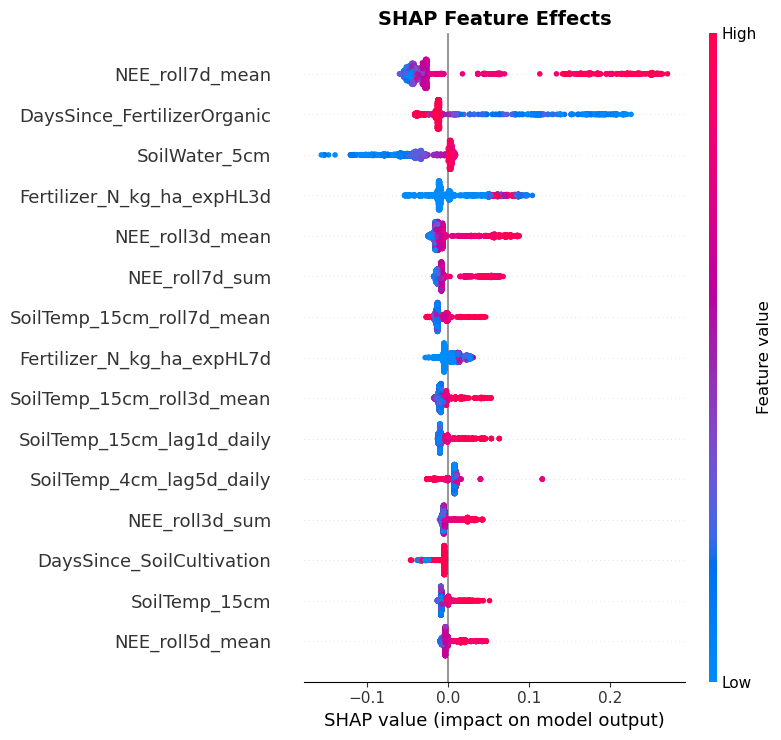

In [8]:
print("="*80)
print("CHAMAU - HOURLY AUGMENTED MODEL")
print("="*80)

chamau_hourly_aug = train_xgb_timeseries_with_shap(
    df=chamau_lag_df,
    predictors=chamau_augmented_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_hyperparams['Hourly_Augmented']
)

## Chamau - Daily Base Model

CHAMAU - DAILY BASE MODEL
Train period: 2014-01-01 00:00:00 → 2021-11-24 00:00:00
Test  period: 2021-11-25 00:00:00 → 2022-07-06 00:00:00
  ✅ No data leakage detected

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.6}

Model evaluation:
  R² (linear scale): 0.142
  Spearman ρ:        0.447

Computing SHAP values...


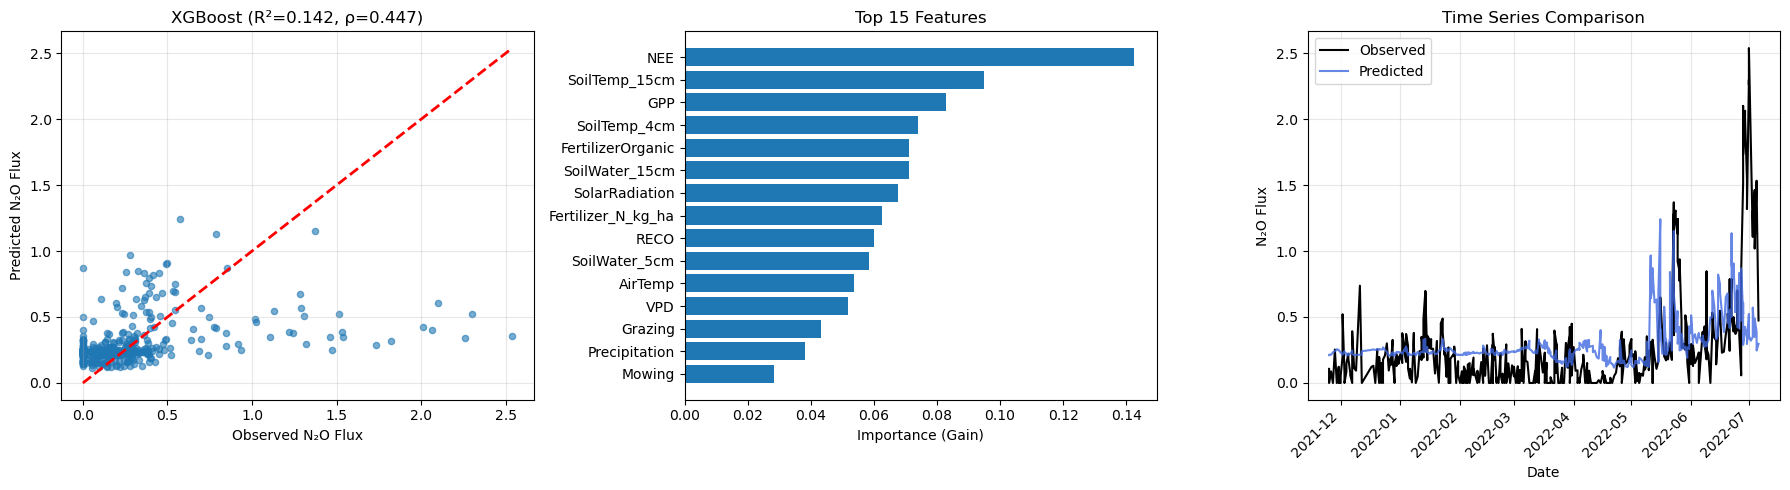

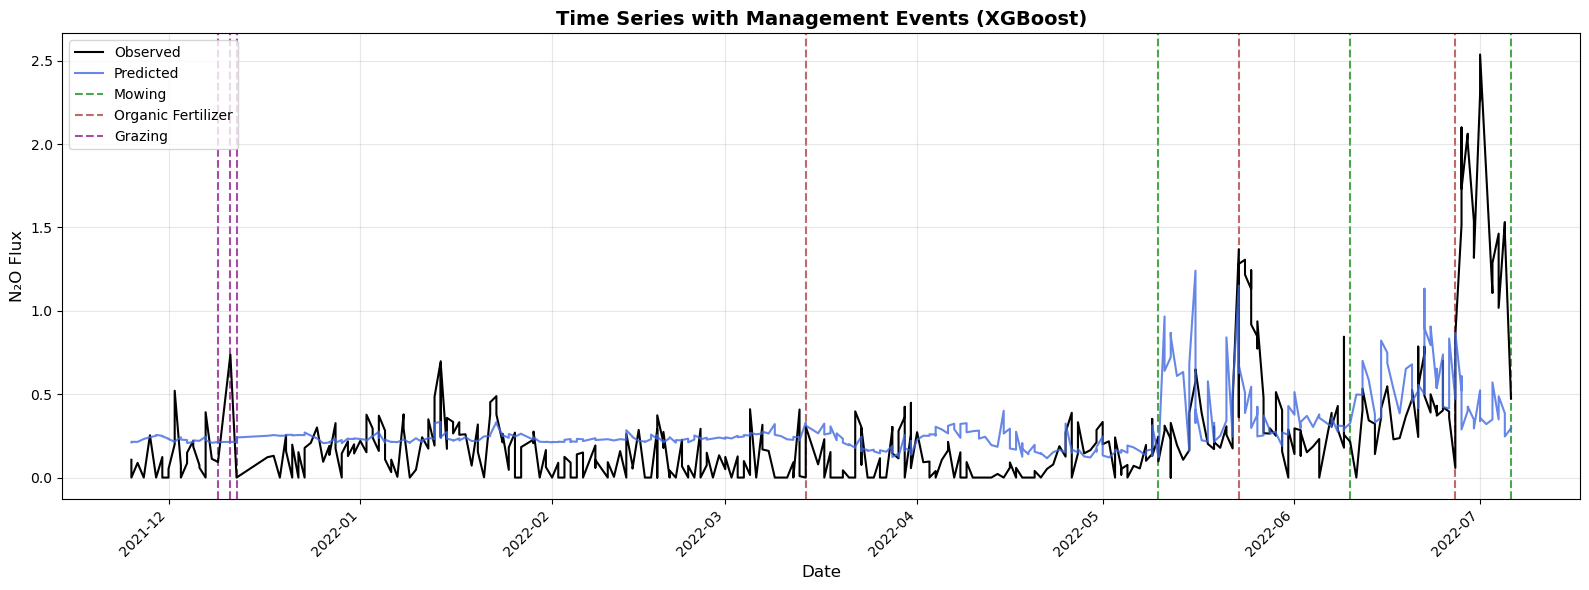

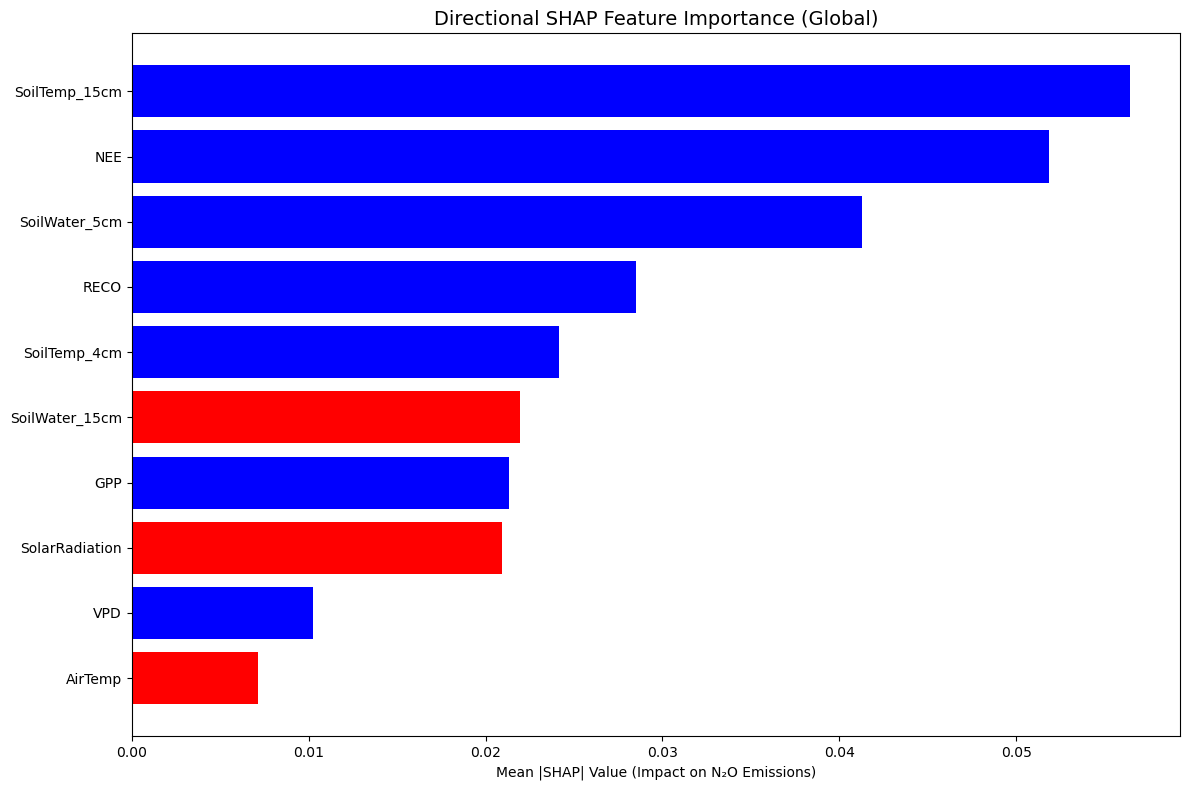

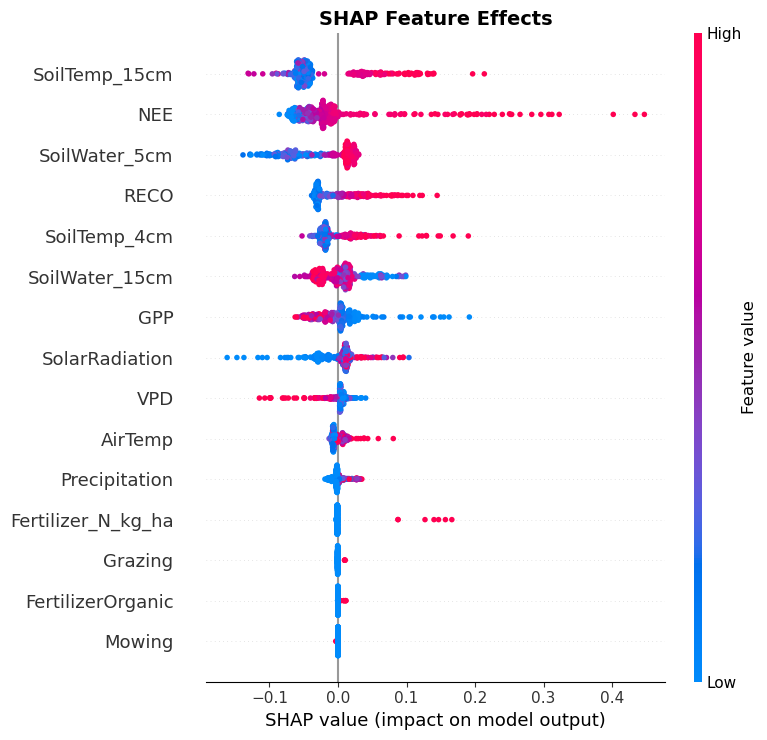

In [9]:
print("="*80)
print("CHAMAU - DAILY BASE MODEL")
print("="*80)

chamau_daily_base = train_xgb_timeseries_with_shap(
    df=chamau_daily_df,
    predictors=chamau_base_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_hyperparams['Daily_Base']
)

## Chamau - Daily Lag & Augmented Models

CHAMAU - DAILY LAG MODEL
Train period: 2014-01-01 00:00:00 → 2021-11-29 00:00:00
Test  period: 2021-11-29 00:00:00 → 2022-07-06 00:00:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.6}

Model evaluation:
  R² (linear scale): 0.333
  Spearman ρ:        0.485

Computing SHAP values...


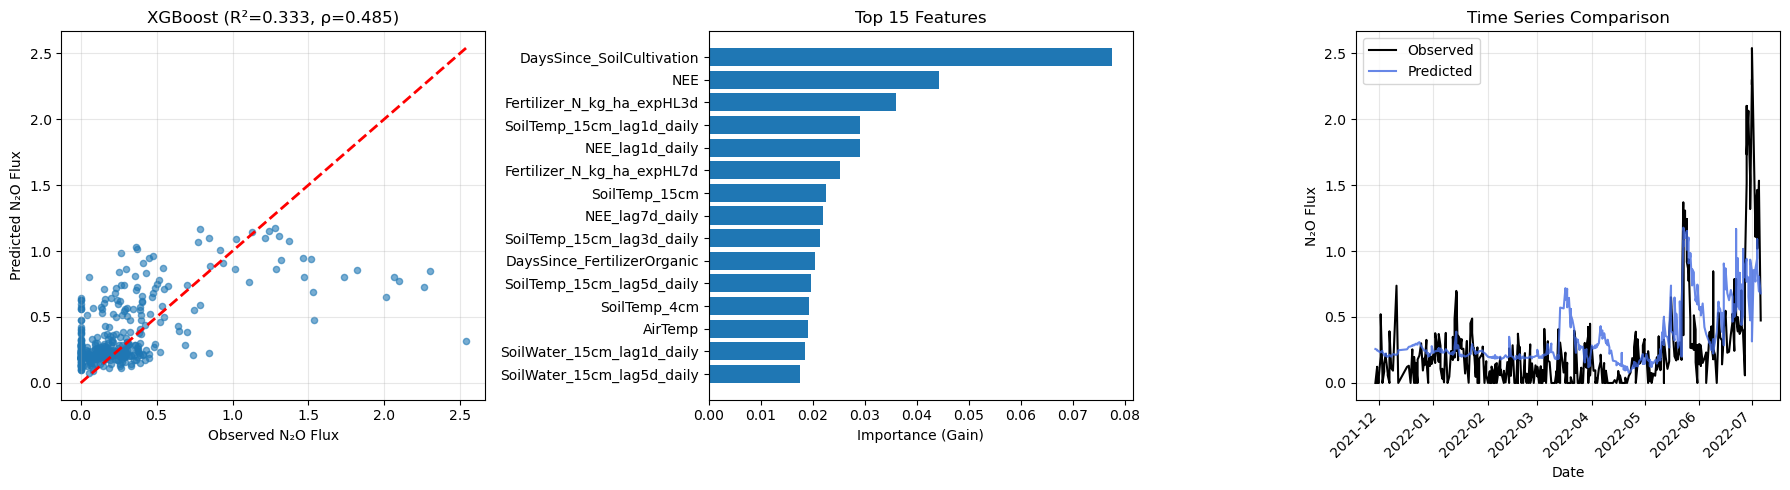

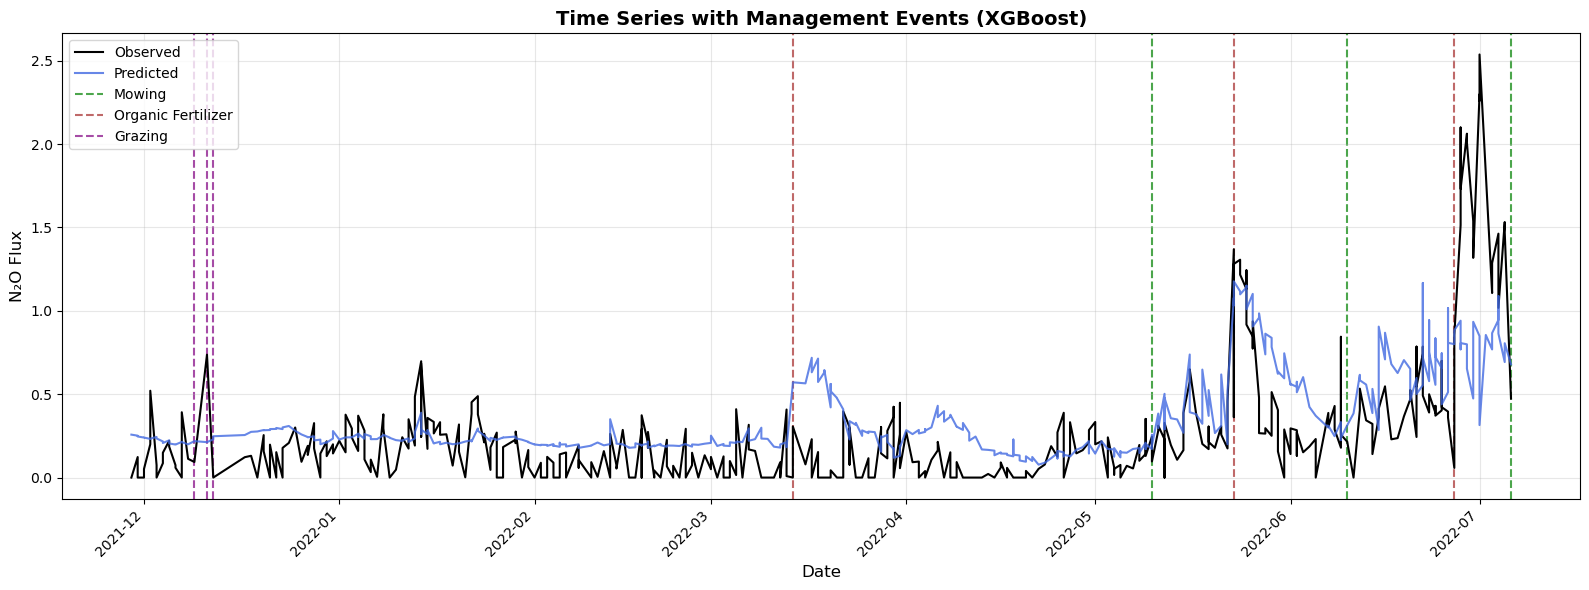

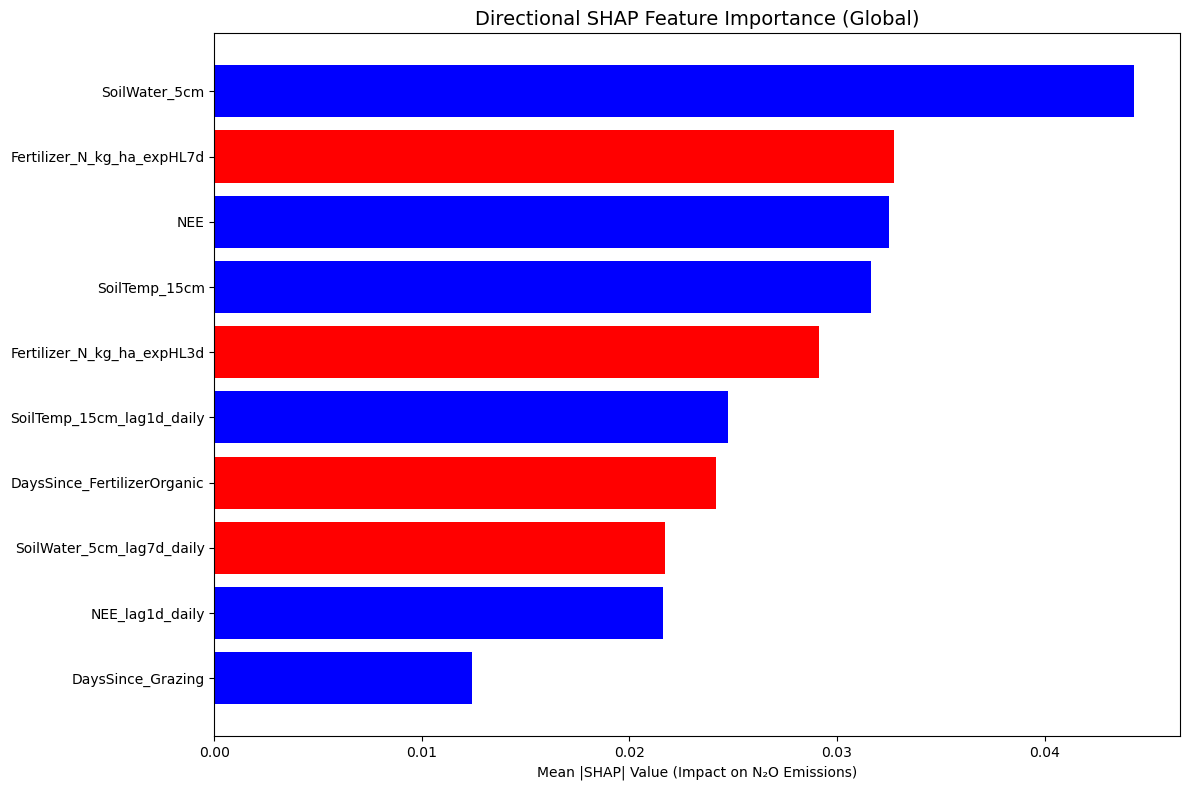

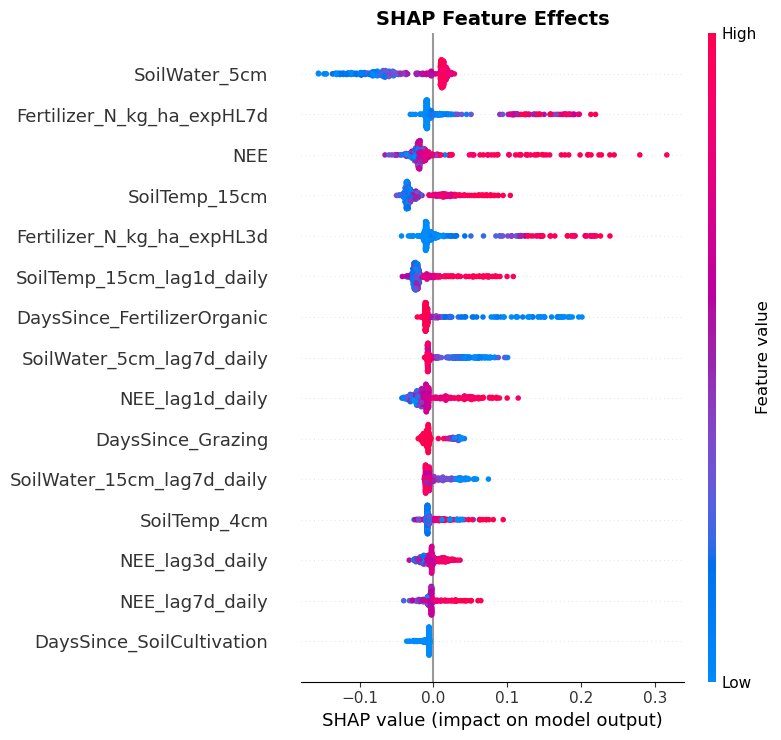


CHAMAU - DAILY AUGMENTED MODEL
Train period: 2014-01-01 00:00:00 → 2021-11-29 00:00:00
Test  period: 2021-11-29 00:00:00 → 2022-07-06 00:00:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0.2, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.6}

Model evaluation:
  R² (linear scale): 0.266
  Spearman ρ:        0.466

Computing SHAP values...


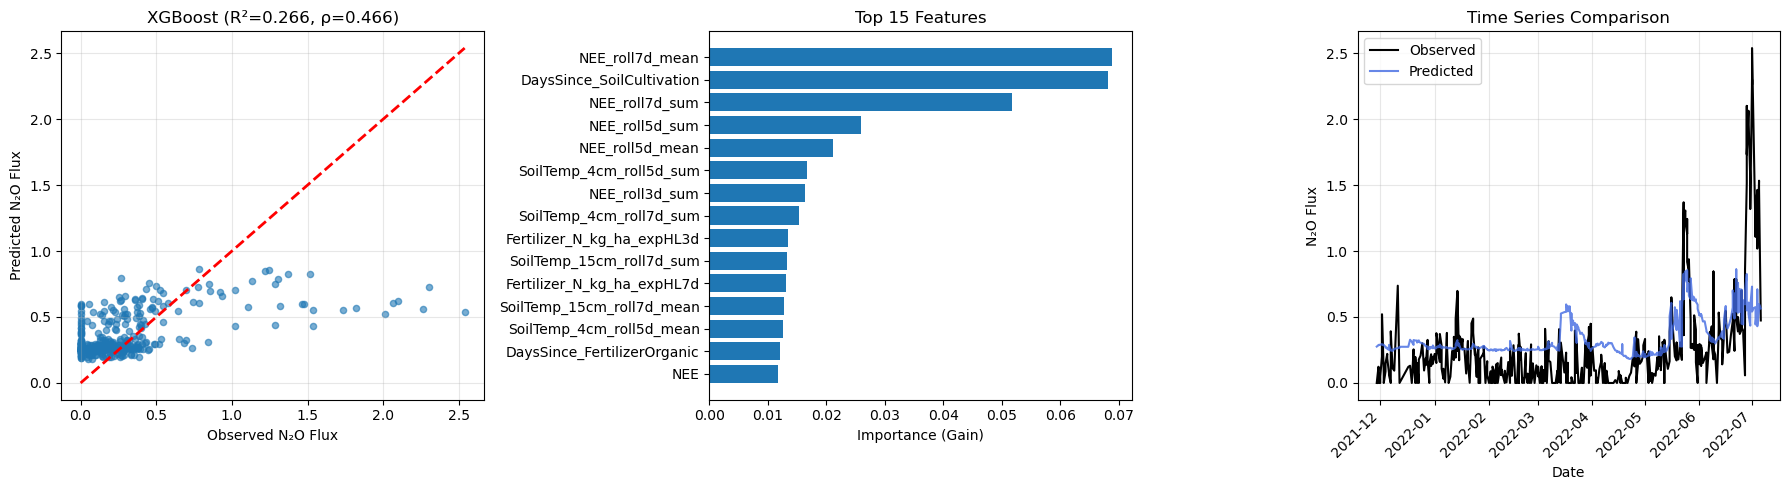

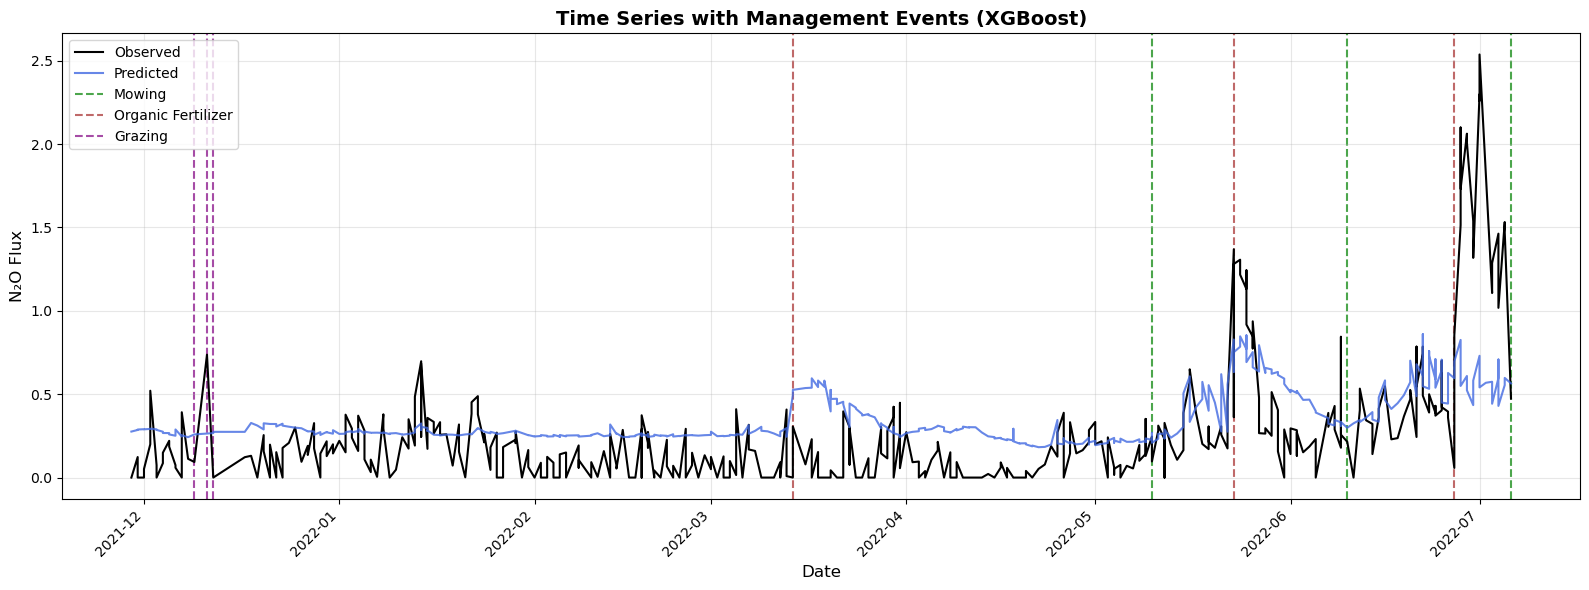

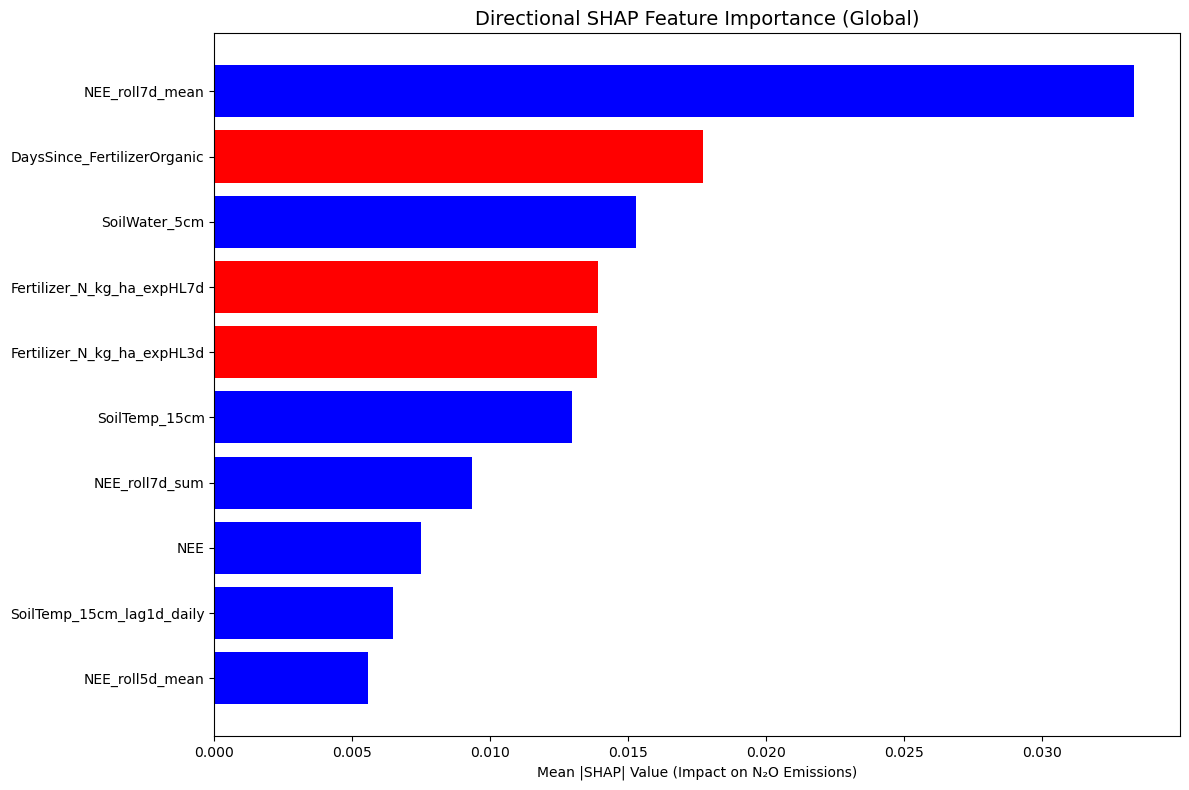

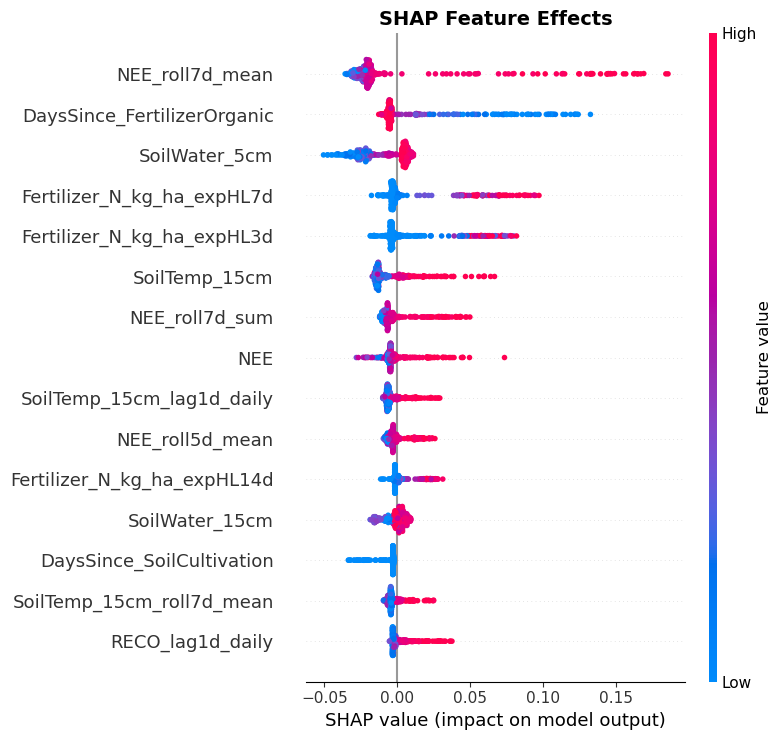

In [10]:
print("="*80)
print("CHAMAU - DAILY LAG MODEL")
print("="*80)

chamau_daily_lag = train_xgb_timeseries_with_shap(
    df=chamau_daily_df,
    predictors=chamau_lag_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_hyperparams['Daily_Lag']
)

print("\n" + "="*80)
print("CHAMAU - DAILY AUGMENTED MODEL")
print("="*80)

chamau_daily_aug = train_xgb_timeseries_with_shap(
    df=chamau_daily_df,
    predictors=chamau_augmented_predictors,
    target='N2O_Flux_ln',
    test_size=0.1,

    hyperparams=chamau_hyperparams['Daily_Augmented']
)

# Dataset 2: Oensingen 2021-23

Oensingen 2021-23 data prepared successfully!
Loaded hyperparameters for 6 experiment settings

OENSINGEN 2021-23 - HOURLY BASE
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.9}

Model evaluation:
  R² (linear scale): 0.102
  Spearman ρ:        0.313

Computing SHAP values...


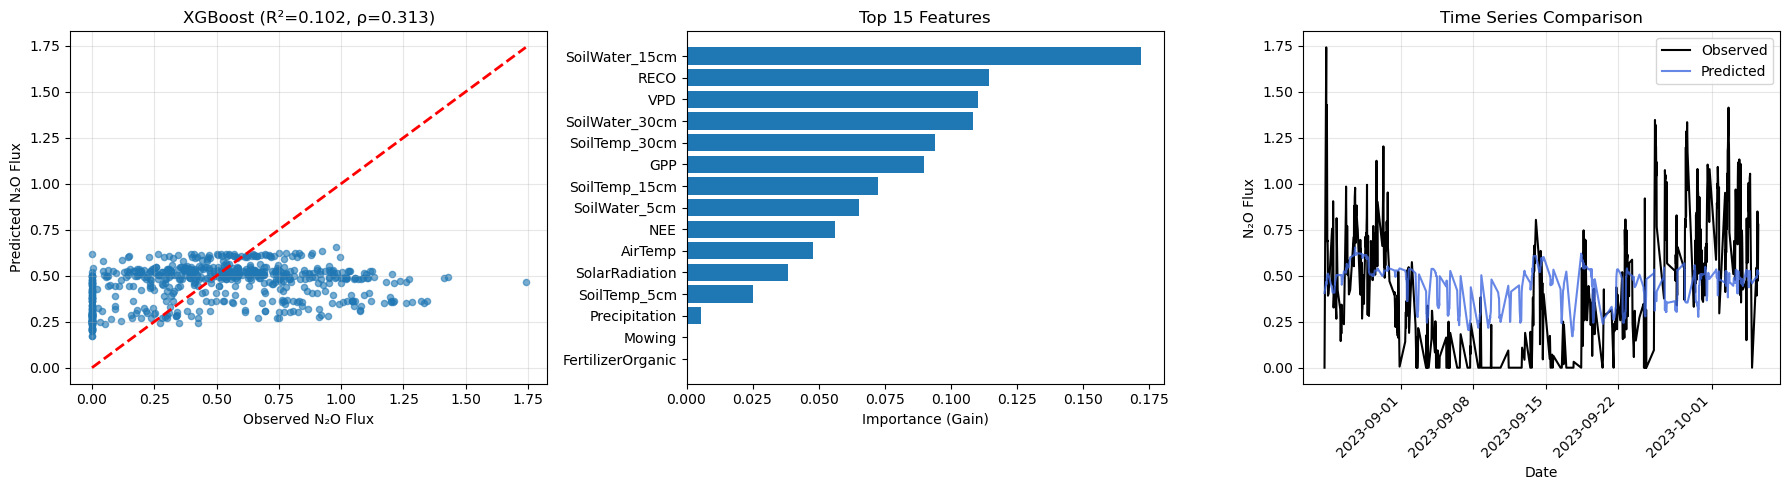

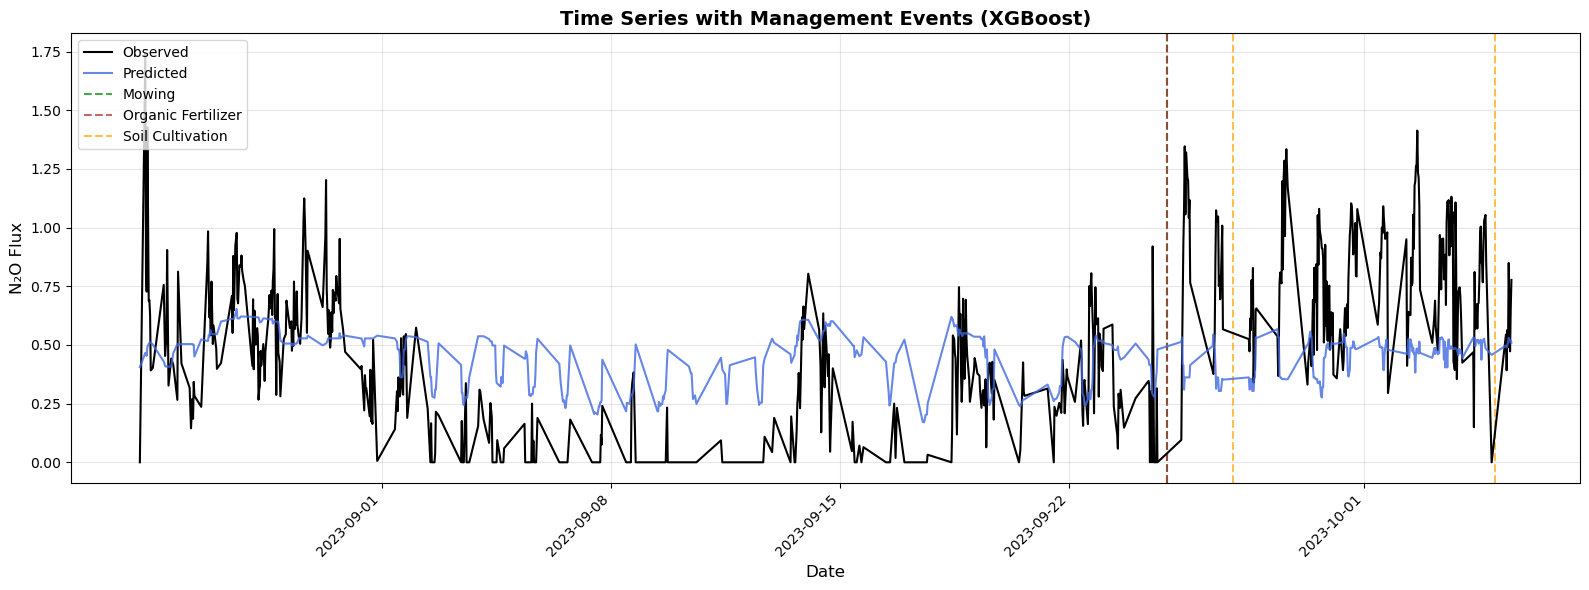

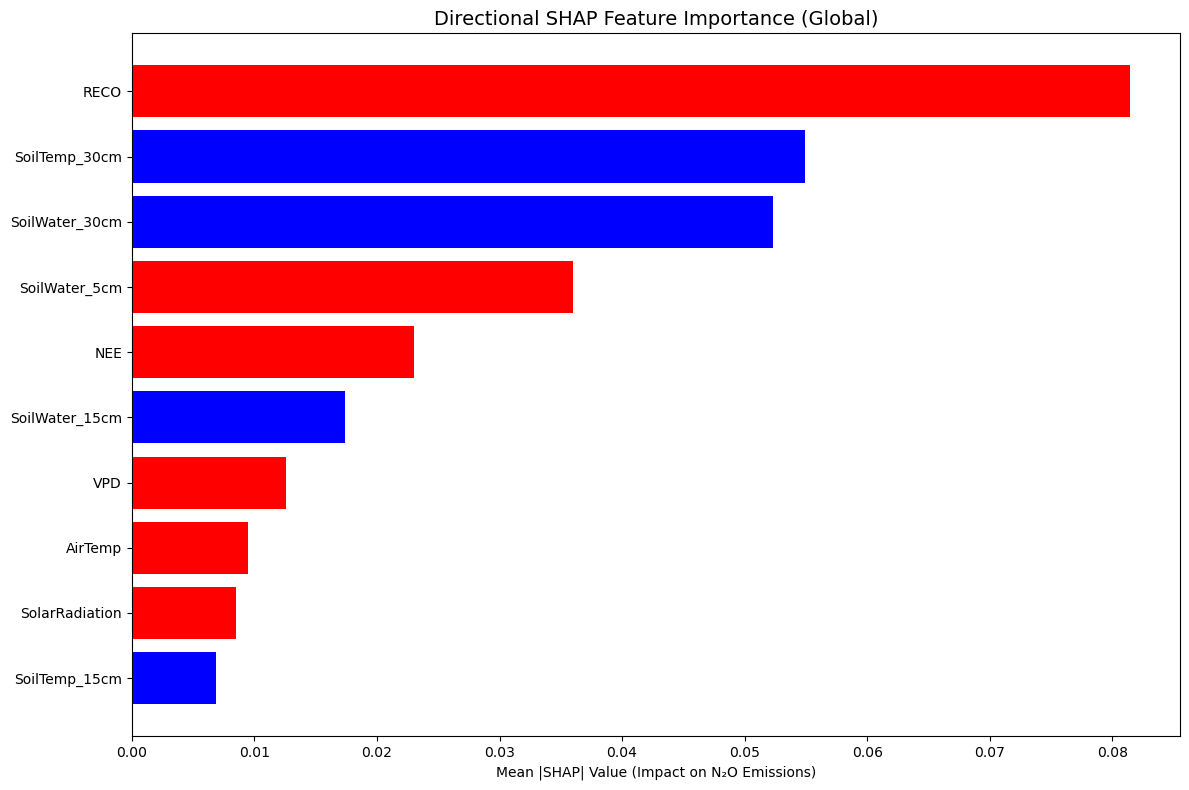

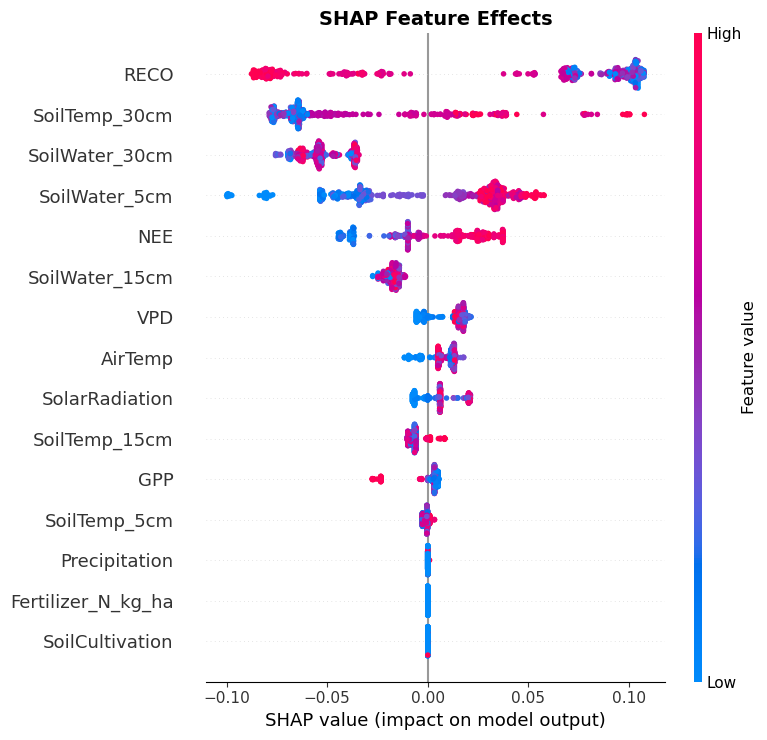


OENSINGEN 2021-23 - HOURLY LAG
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'random_state': 42}

Model evaluation:
  R² (linear scale): 0.097
  Spearman ρ:        0.694

Computing SHAP values...


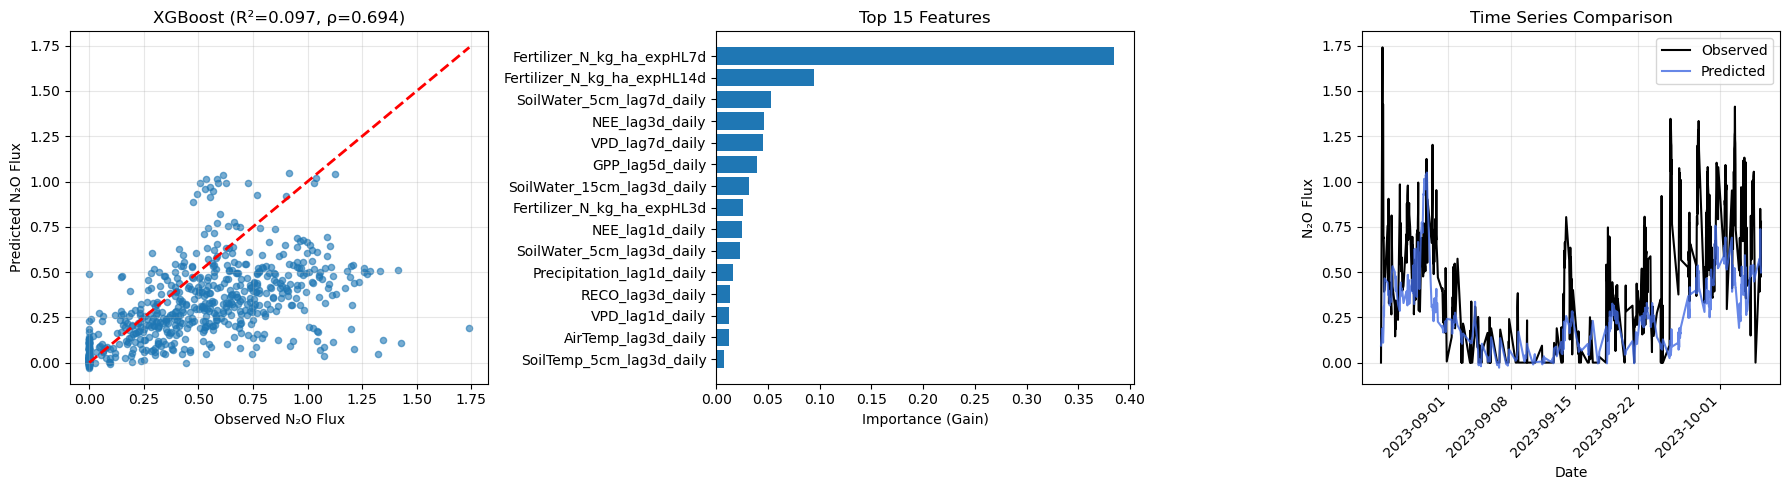

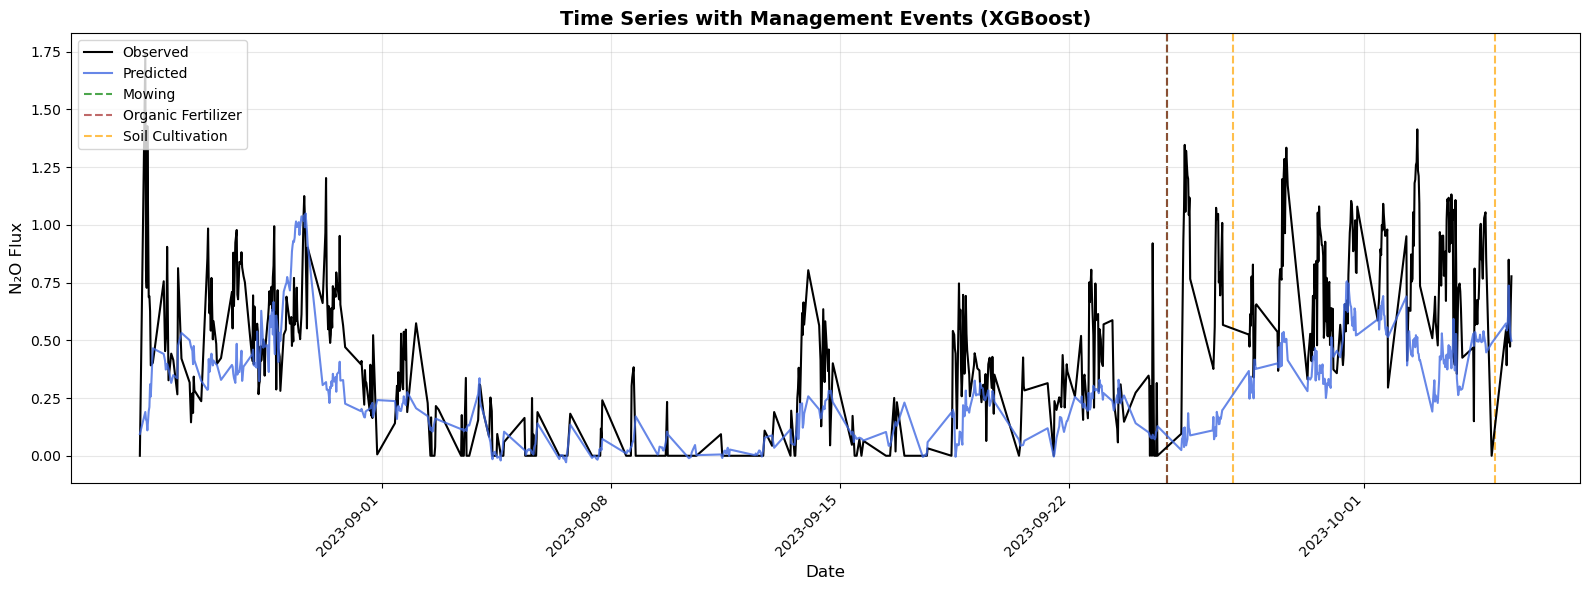

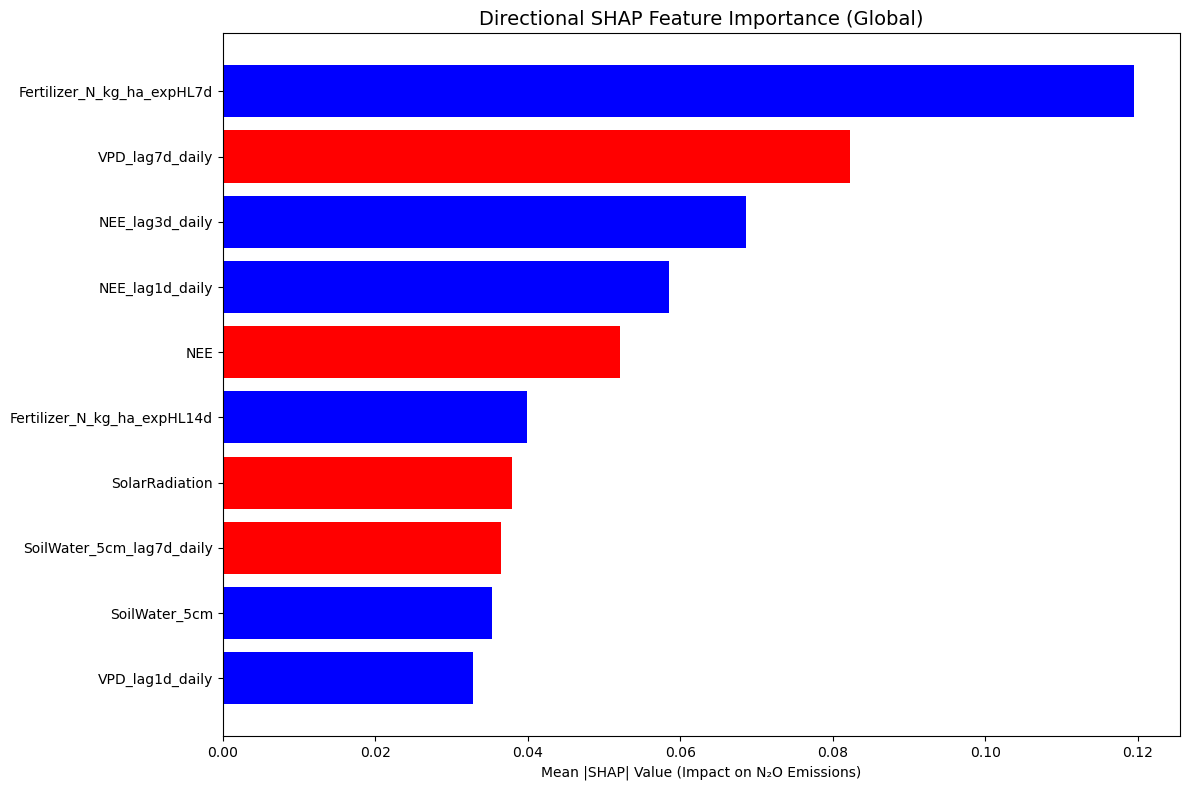

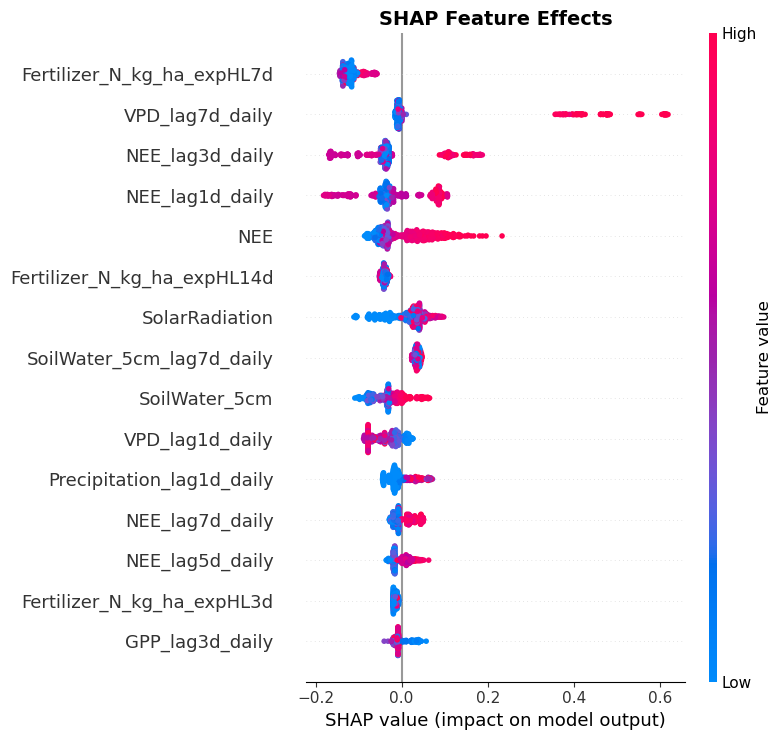


OENSINGEN 2021-23 - HOURLY AUGMENTED
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  ⚠️  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'colsample_bytree': 0.6, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.7}

Model evaluation:
  R² (linear scale): 0.157
  Spearman ρ:        0.700

Computing SHAP values...


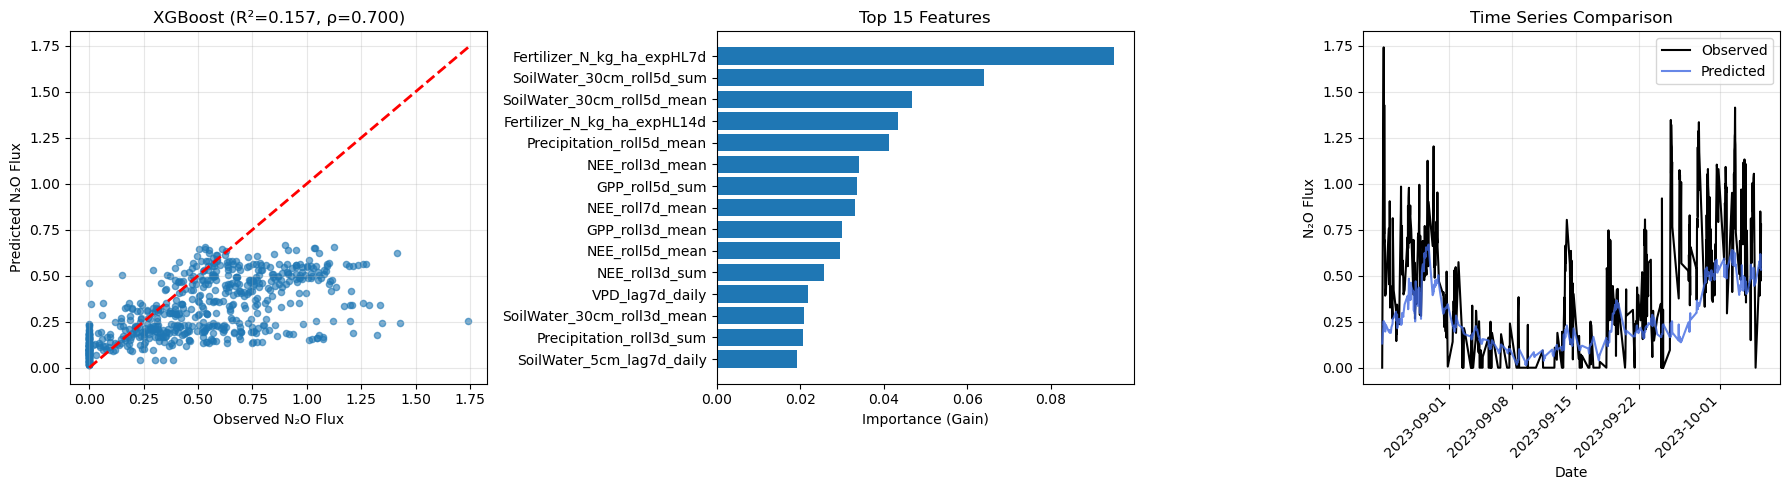

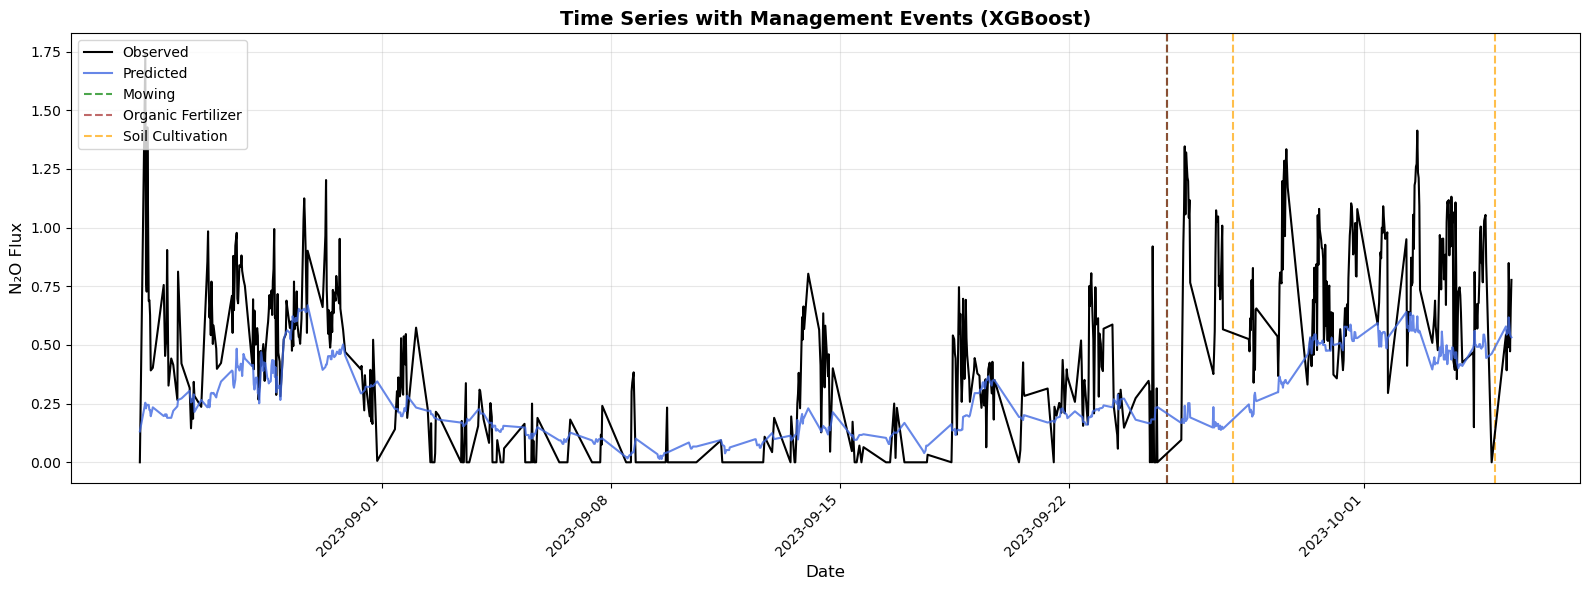

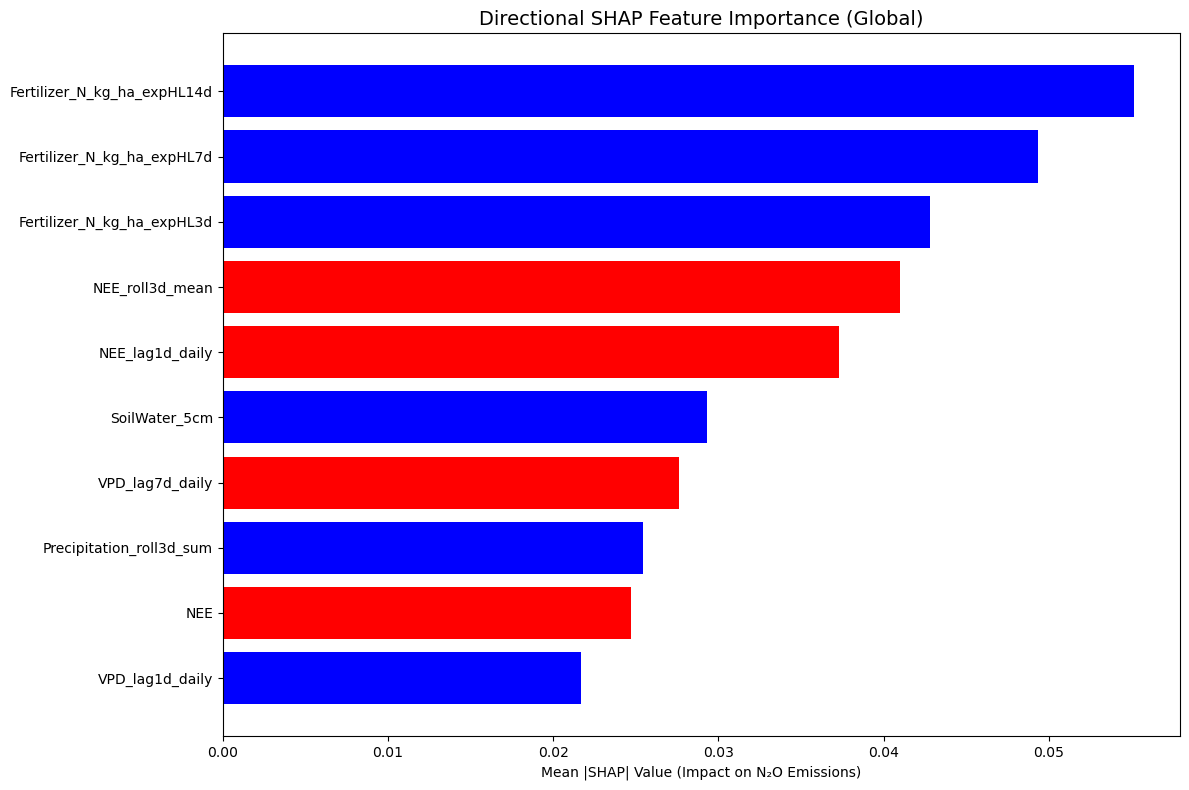

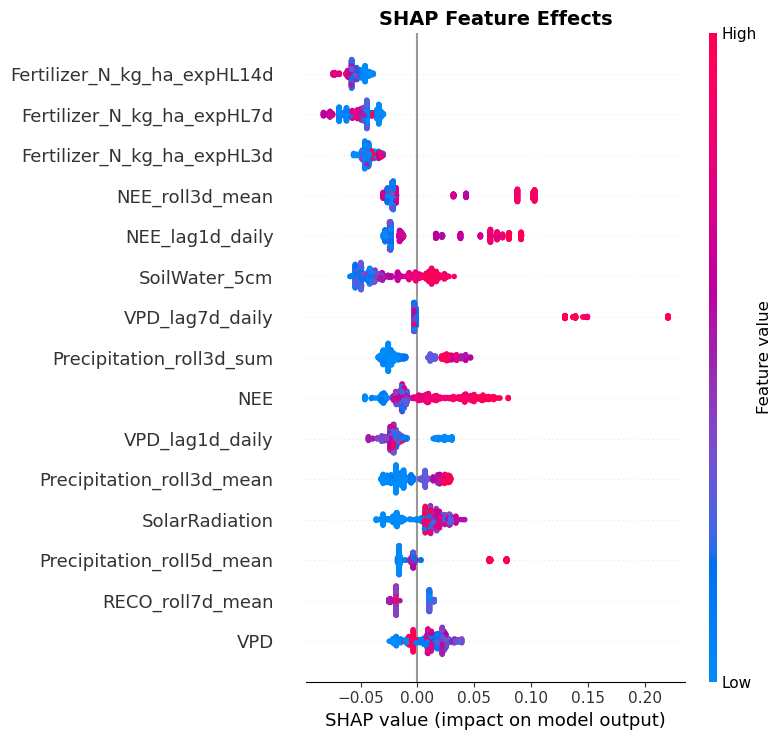


OENSINGEN 2021-23 - DAILY BASE
Train period: 2022-08-30 00:00:00 → 2023-08-28 00:00:00
Test  period: 2023-08-29 00:00:00 → 2023-10-05 00:00:00
  ✅ No data leakage detected

Using custom hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'random_state': 42}

Model evaluation:
  R² (linear scale): 0.591
  Spearman ρ:        0.835

Computing SHAP values...


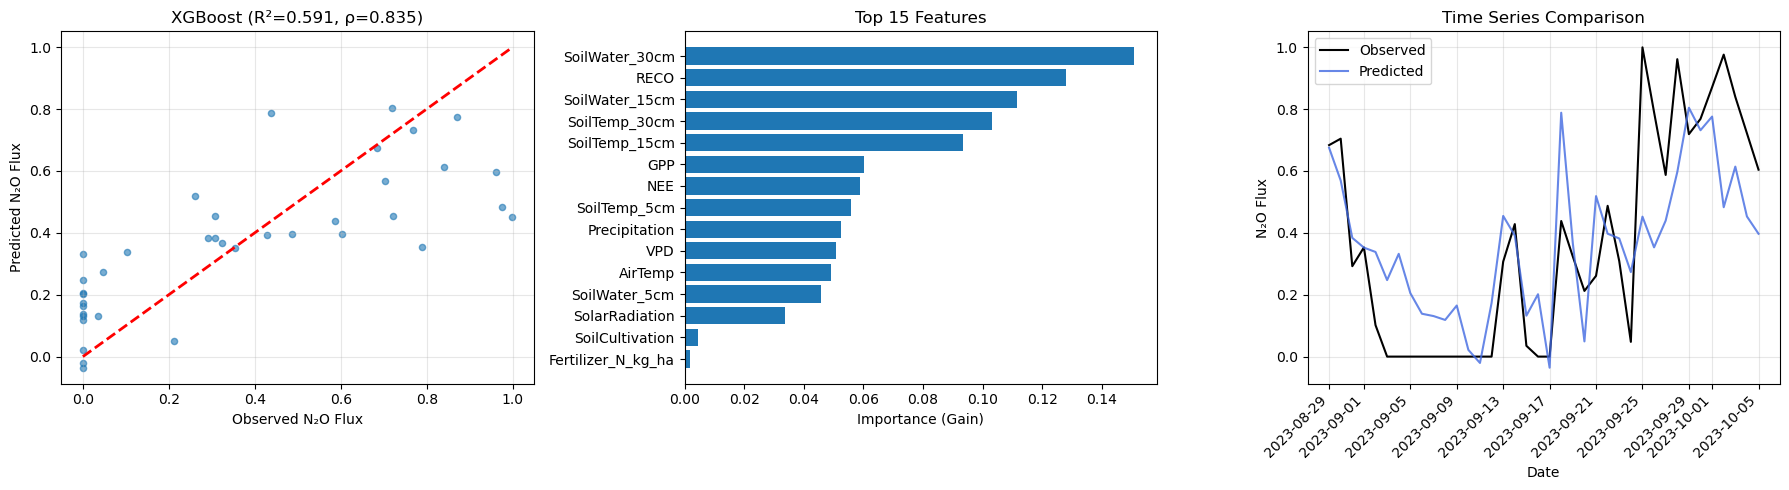

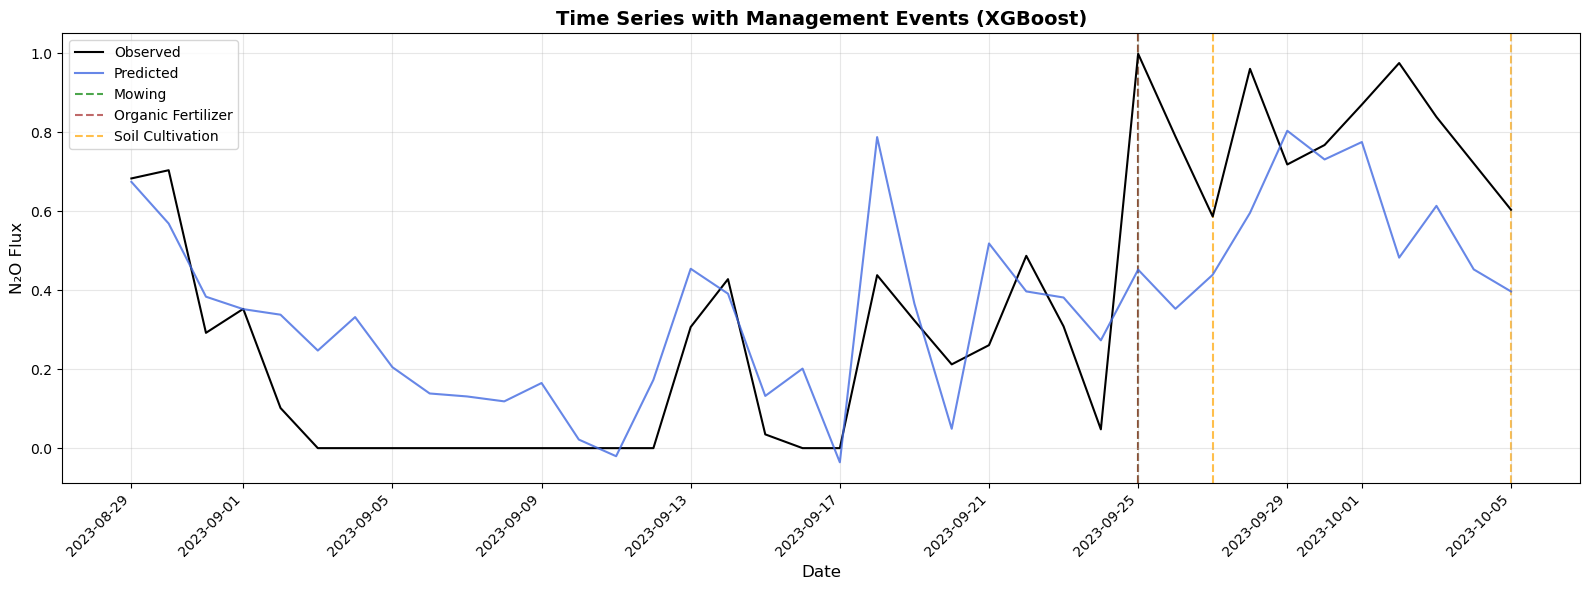

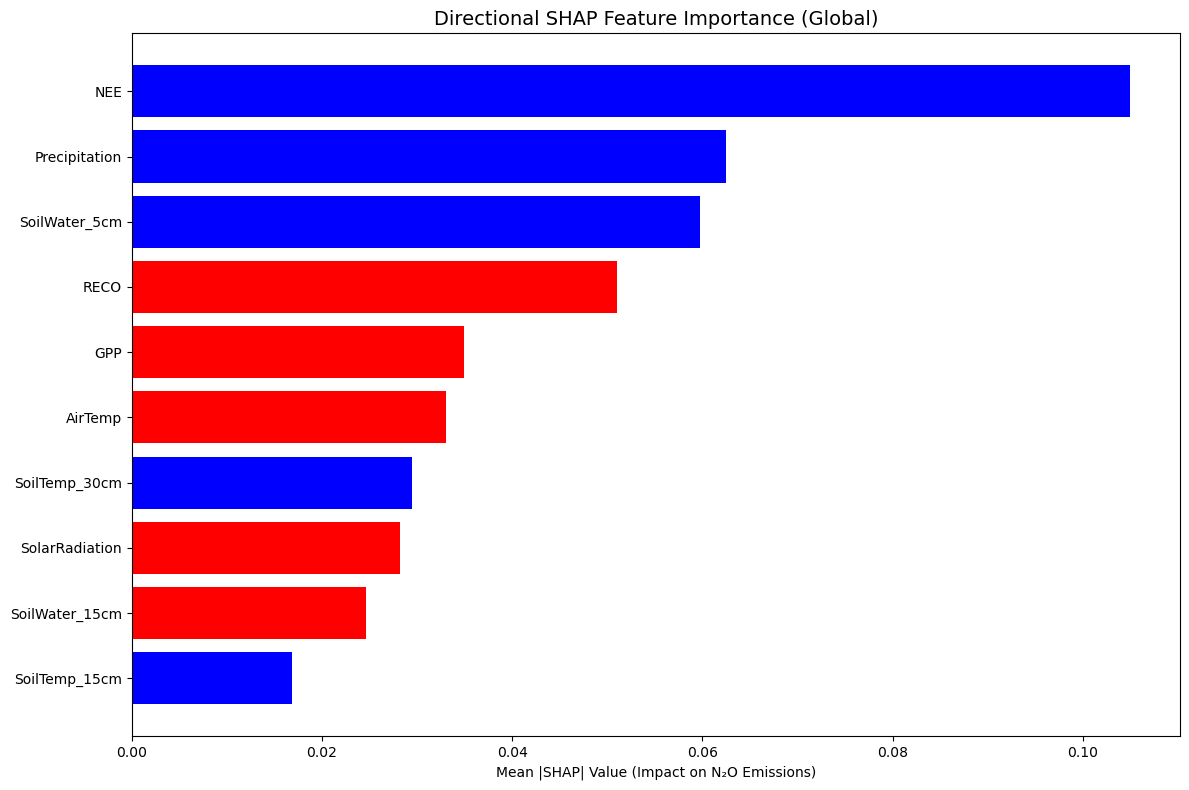

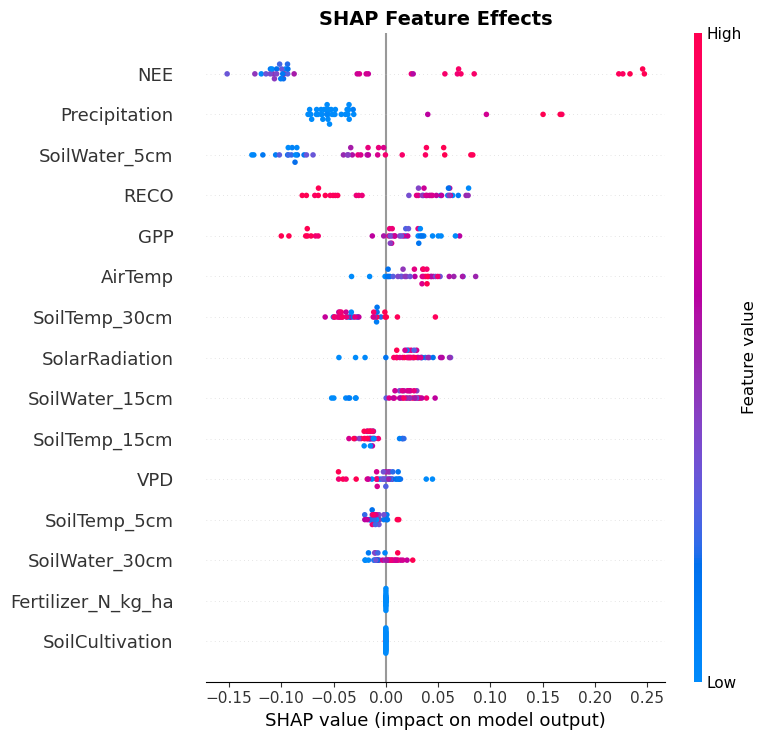


OENSINGEN 2021-23 - DAILY LAG
Train period: 2022-09-06 00:00:00 → 2023-08-29 00:00:00
Test  period: 2023-08-30 00:00:00 → 2023-10-05 00:00:00
  ✅ No data leakage detected

Using custom hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'random_state': 42}

Model evaluation:
  R² (linear scale): 0.381
  Spearman ρ:        0.746

Computing SHAP values...


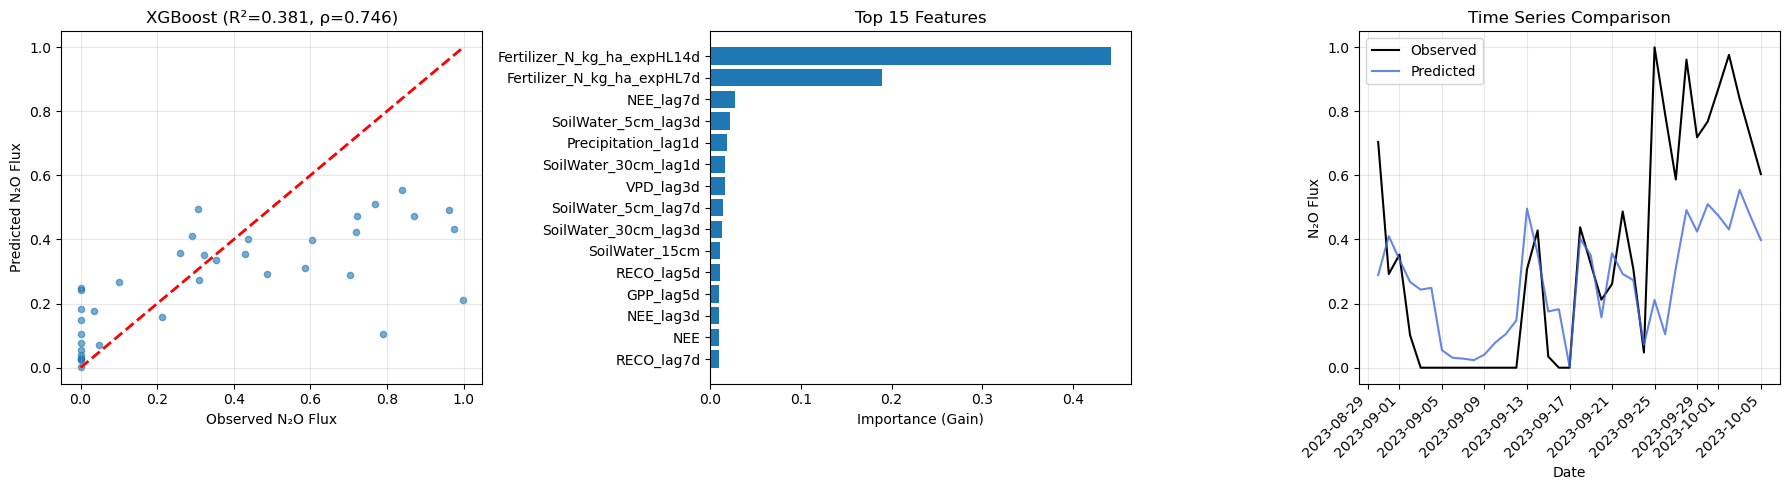

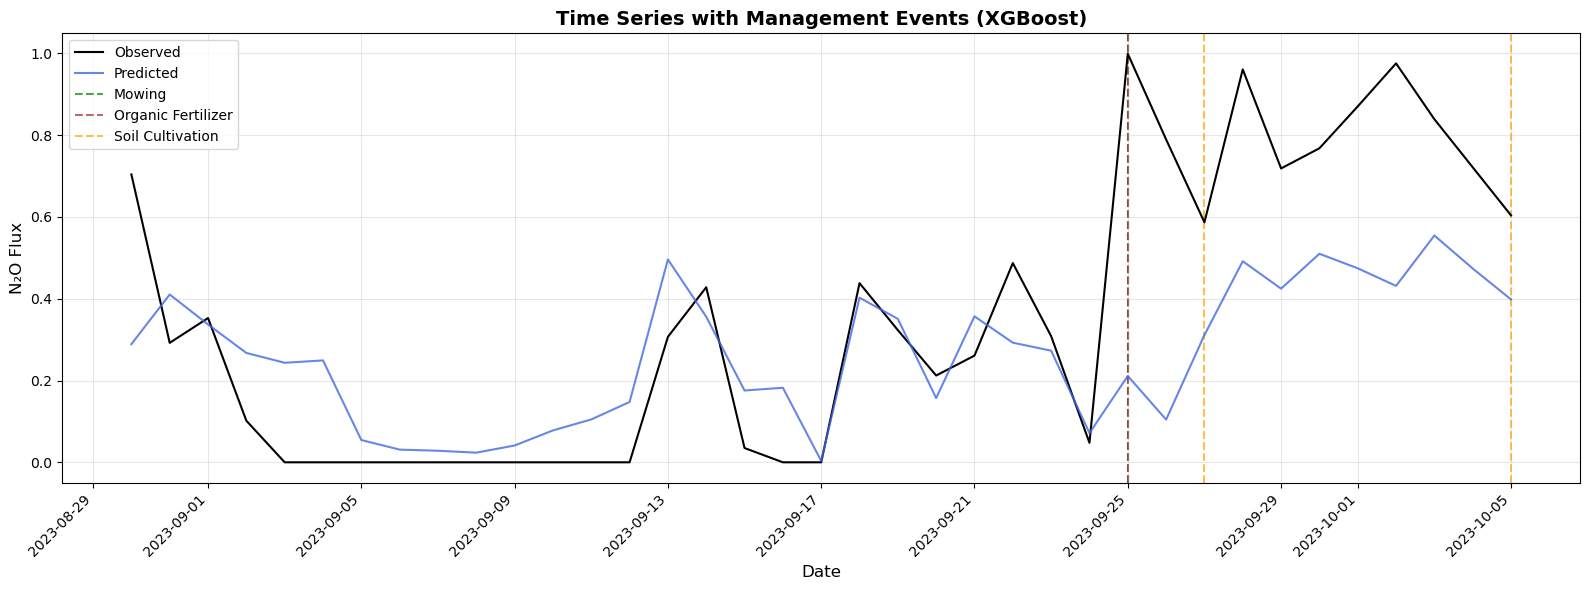

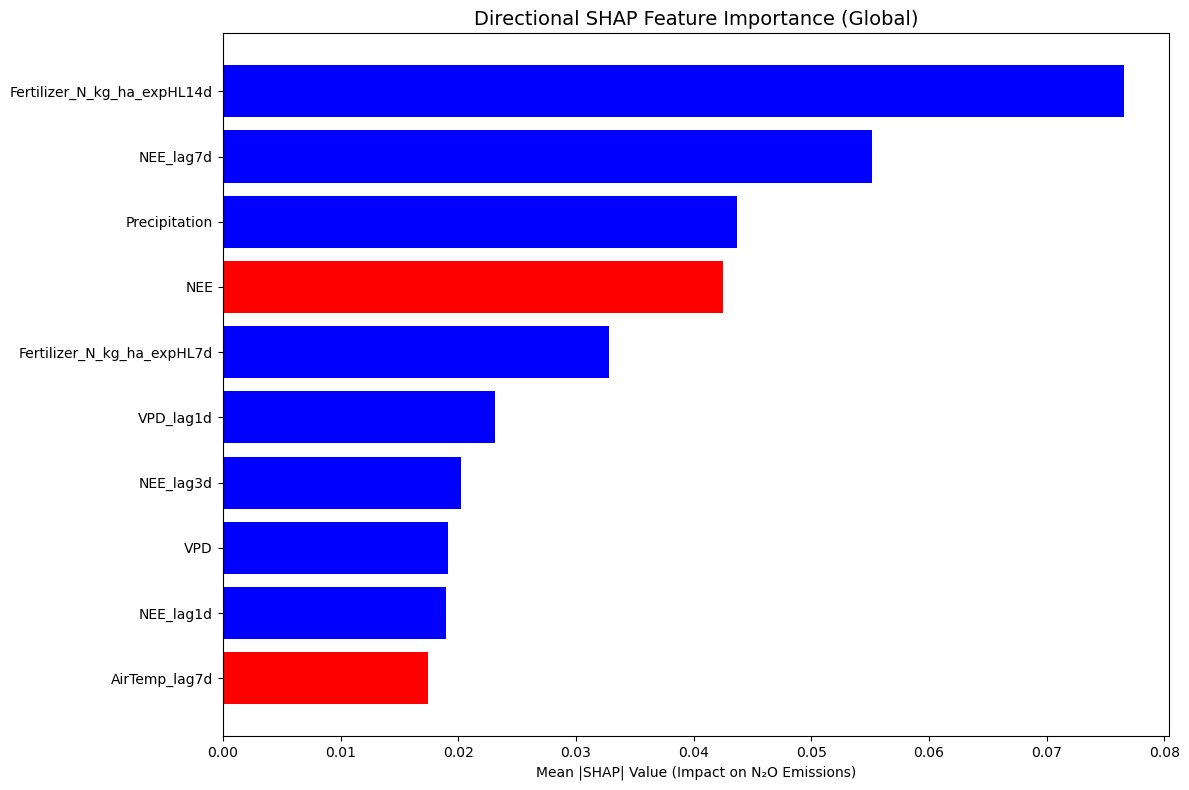

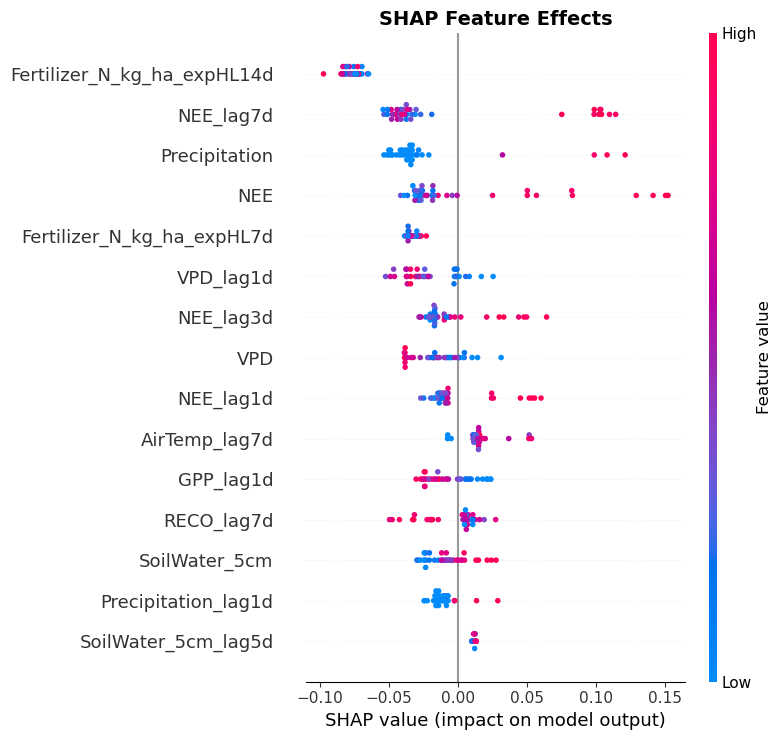


OENSINGEN 2021-23 - DAILY AUGMENTED
Train period: 2022-09-06 00:00:00 → 2023-08-29 00:00:00
Test  period: 2023-08-30 00:00:00 → 2023-10-05 00:00:00
  ✅ No data leakage detected

Using custom hyperparameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'random_state': 42}

Model evaluation:
  R² (linear scale): 0.177
  Spearman ρ:        0.551

Computing SHAP values...


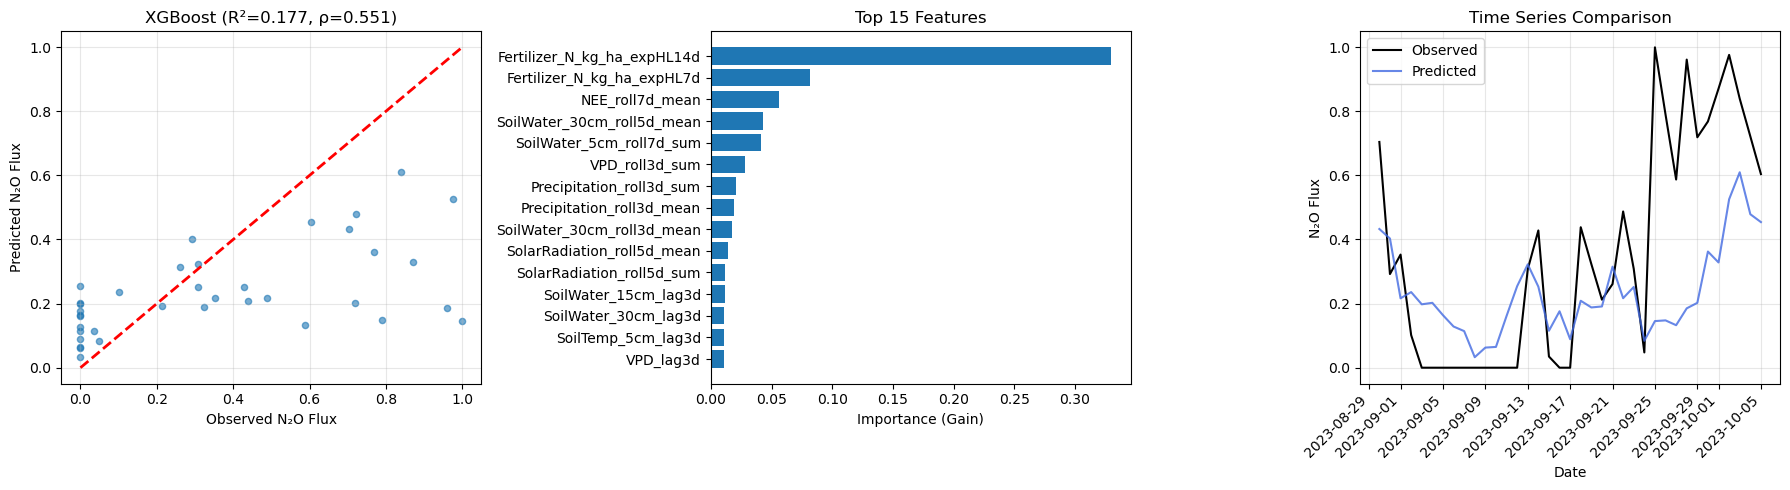

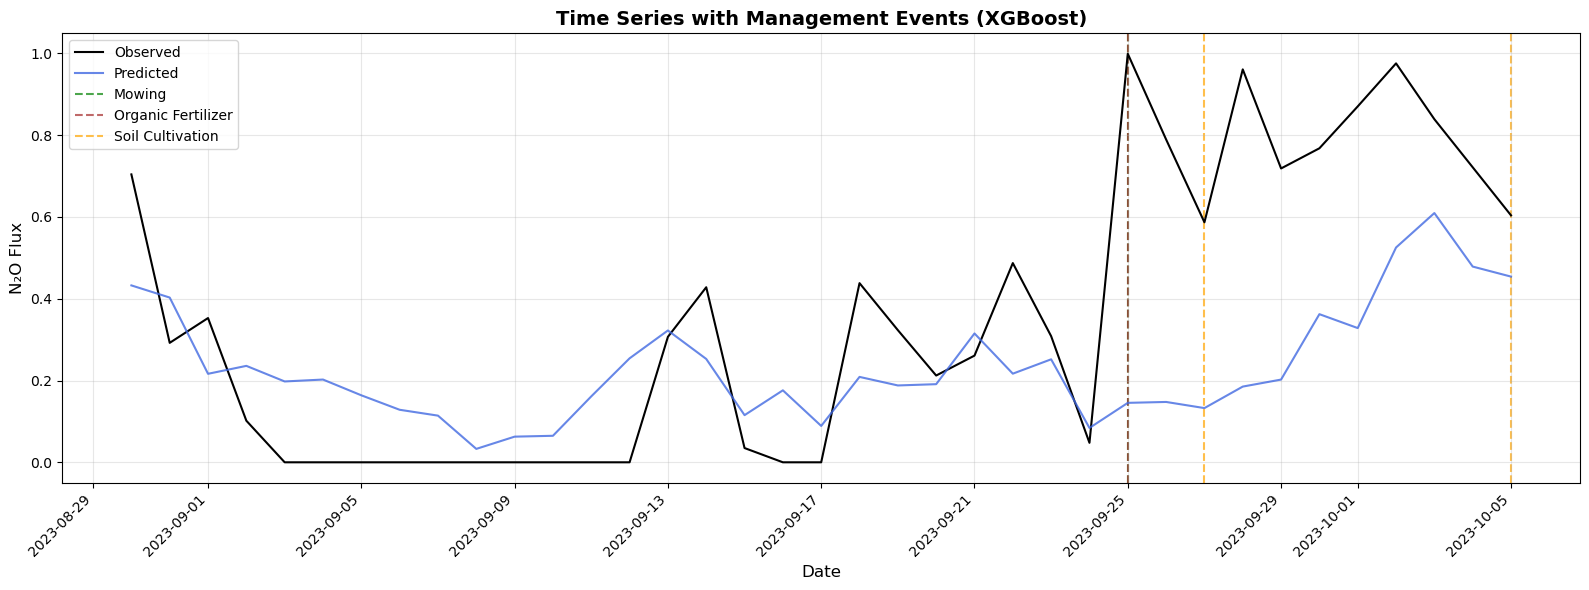

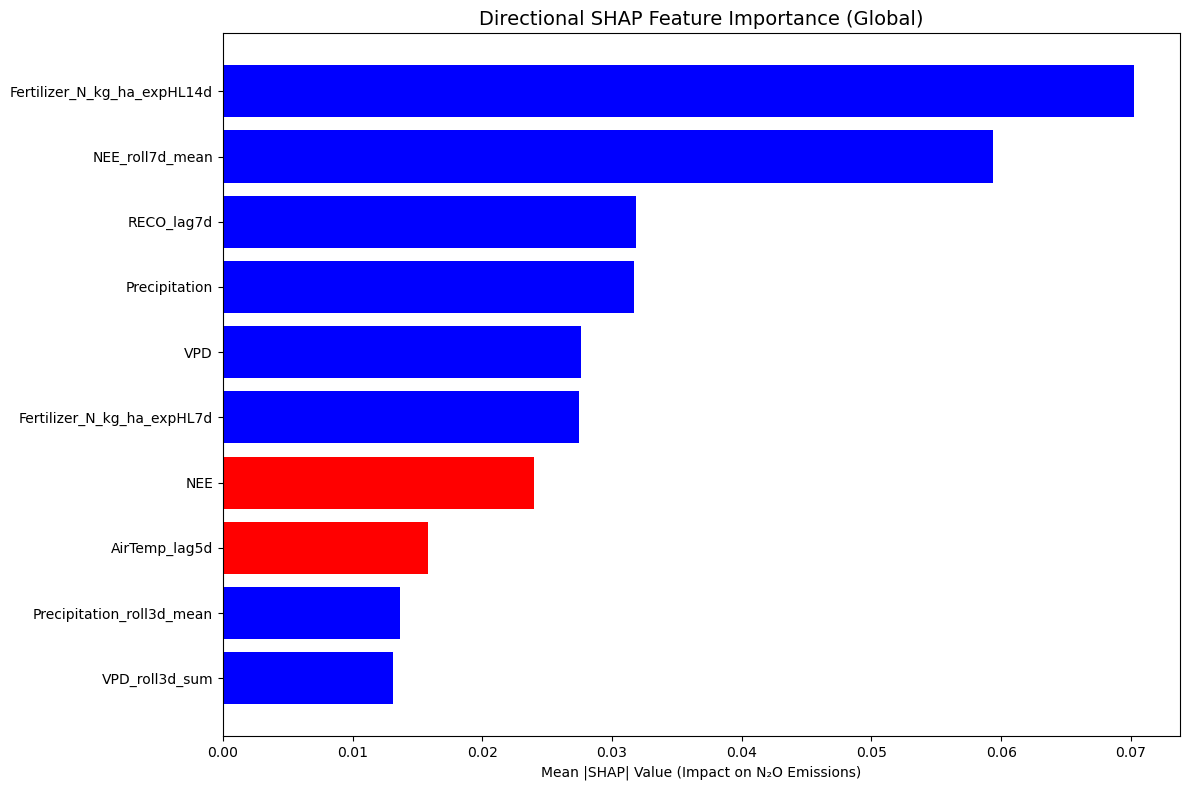

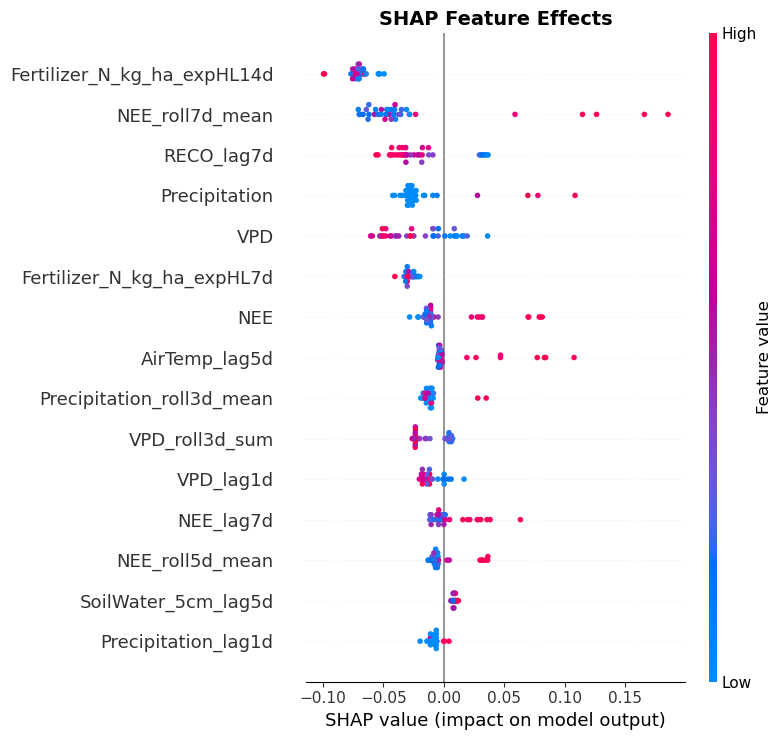

In [11]:
# Prepare Oensingen 2021-23 data (using .copy() to avoid modifying original dataframes)
# IMPORTANT: Match XGBoost_experiments.ipynb EXACTLY for data preparation
oensingen_2_lag_df = oensingen_2_lag.copy()
oensingen_2_lag_df['Timestamp'] = pd.to_datetime(oensingen_2_lag_df['Timestamp'])
oensingen_2_lag_df = oensingen_2_lag_df.set_index('Timestamp').sort_index()

# For daily: XGBoost_experiments does NOT set Date as index, just sorts by it
oensingen_2_daily_df = oensingen_2_daily.copy()
oensingen_2_daily_df['Date'] = pd.to_datetime(oensingen_2_daily_df['Date'])
oensingen_2_daily_df = oensingen_2_daily_df.sort_values('Date')  # NOT set_index - matches XGBoost_experiments exactly

# Load best performing hyperparameters for Oensingen 2021-23
with open("xgboost_params/Oensingen_2021-23/best_performing_hyperparameters.json", "r") as f:
    oensingen_2_hyperparams = json.load(f)

print("Oensingen 2021-23 data prepared successfully!")
print(f"Loaded hyperparameters for {len(oensingen_2_hyperparams)} experiment settings")

# Run all experiments for Oensingen 2021-23
experiments = [
    ("Hourly_Base", oensingen_2_lag_df, base_predictors),
    ("Hourly_Lag", oensingen_2_lag_df, hourly_lag_predictors),
    ("Hourly_Augmented", oensingen_2_lag_df, hourly_augmented_predictors),
    ("Daily_Base", oensingen_2_daily_df, base_predictors),
    ("Daily_Lag", oensingen_2_daily_df, daily_lag_predictors),
    ("Daily_Augmented", oensingen_2_daily_df, daily_augmented_predictors),
]

oensingen_2_results = {}
for exp_name, df, predictors in experiments:
    print("\n" + "="*80)
    print(f"OENSINGEN 2021-23 - {exp_name.upper().replace('_', ' ')}")
    print("="*80)
    
    oensingen_2_results[exp_name] = train_xgb_timeseries_with_shap(
        df=df,
        predictors=predictors,
        target='N2O_Flux_ln',
        test_size=0.1,
        hyperparams=oensingen_2_hyperparams[exp_name]
    )

In [12]:
def train_rf_timeseries_with_shap(df, predictors, target, test_size=0.1, hyperparams=None, random_state=42, plot=True):
    """
    Train Random Forest on time-series data using chronological split with SHAP analysis.
    
    Parameters:
    -----------
    df : DataFrame - Input data
    predictors : list - Feature column names
    target : str - Target column name
    test_size : float - Fraction of data for testing (default 0.1)
    hyperparams : dict - RF hyperparameters (if None, uses defaults)
    random_state : int - Random seed
    plot : bool - Whether to generate plots
    """
    
    # EXTRACT FEATURES/TARGET
    X = df[predictors]
    y = df[target]
    
    # HANDLE NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # OFFSET FOR POSITIVITY
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # CHRONOLOGICAL SPLIT
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # Store test dates for time series plot
    # For hourly data: index is Timestamp
    # For daily data: index is integer, need to get Date column
    try:
        # Check if index has .date attribute (datetime index)
        _ = X_test.index.date
        test_dates = X_test.index
        is_datetime_index = True
    except AttributeError:
        # Daily data - get dates from Date column
        if 'Date' in df.columns:
            test_dates = df.loc[X_test.index, 'Date']
        else:
            test_dates = X_test.index  # Fallback to integer index
        is_datetime_index = False
    
    # Get time ranges for printing
    if is_datetime_index:
        time_train = (df.index.min(), df.index[:split_idx].max())
        time_test = (df.index[split_idx], df.index.max())
    else:
        if 'Date' in df.columns:
            train_indices = X_train.index
            test_indices = X_test.index
            time_train = (df.loc[train_indices, 'Date'].min(), df.loc[train_indices, 'Date'].max())
            time_test = (df.loc[test_indices, 'Date'].min(), df.loc[test_indices, 'Date'].max())
        else:
            time_train = (df.index.min(), df.index[:split_idx].max())
            time_test = (df.index[split_idx], df.index.max())
    
    print(f"Train period: {time_train[0]} → {time_train[1]}")
    print(f"Test  period: {time_test[0]} → {time_test[1]}")
    
    # DATA LEAKAGE CHECK
    try:
        train_dates_set = set(X_train.index.date)
        test_dates_set = set(X_test.index.date)
    except AttributeError:
        train_indices = X_train.index
        test_indices = X_test.index
        
        if 'Date' in df.columns:
            train_dates_set = set(pd.to_datetime(df.loc[train_indices, 'Date']).dt.date)
            test_dates_set = set(pd.to_datetime(df.loc[test_indices, 'Date']).dt.date)
        else:
            train_dates_set = set()
            test_dates_set = set()
            print("  Cannot check for data leakage (no Date column found)")
    
    overlap_dates = train_dates_set & test_dates_set
    if len(overlap_dates) > 0:
        print(f"  DATA LEAKAGE WARNING: {len(overlap_dates)} dates appear in BOTH train and test!")
    else:
        print(f"  No data leakage detected")
    
    # DEFAULT HYPERPARAMETERS
    default_params = {
        'n_estimators': 500,
        'max_depth': 20,
        'min_samples_split': 5,
        'min_samples_leaf': 5,
        'max_features': 0.3,
        'random_state': random_state,
        'n_jobs': -1
    }
    
    # Merge with provided hyperparams (provided params override defaults)
    if hyperparams is not None:
        model_params = {**default_params, **hyperparams}
        print(f"\nUsing custom hyperparameters: {hyperparams}")
    else:
        model_params = default_params
        print("\nUsing default hyperparameters")
    
    # Ensure n_jobs and random_state are set
    model_params['n_jobs'] = -1
    if 'random_state' not in model_params:
        model_params['random_state'] = random_state

    print(f"RF model params: {model_params}")
    
    # TRAIN MODEL
    model = RandomForestRegressor(**model_params)
    model.fit(X_train, y_train)
    
    # PREDICTIONS
    y_pred = model.predict(X_test)
    
    # REVERT OFFSET
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    # EVALUATION
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    # FEATURE IMPORTANCE
    importances = pd.Series(model.feature_importances_, index=predictors).sort_values(ascending=False)
    
    print("\nModel evaluation:")
    print(f"  R² (linear scale): {r2:.3f}")
    print(f"  Spearman ρ:        {rho:.3f}")
    
    # ========== SHAP ANALYSIS ==========
    print("\nComputing SHAP values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # PLOT
    if plot:
        # Create 3-subplot figure: scatter, feature importance, and TIME SERIES
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Scatter plot
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"Random Forest (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # 2. Feature importance
        top_features = importances.head(15)
        axes[1].barh(range(len(top_features)), top_features.values)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel("Importance (Gini)")
        axes[1].set_title("Top 15 Features")
        axes[1].invert_yaxis()
        
        # 3. TIME SERIES COMPARISON (now uses correct dates for daily data)
        axes[2].plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5)
        axes[2].plot(test_dates, y_pred_lin, label="Predicted", color="forestgreen", lw=1.5, alpha=0.8)
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("N₂O Flux")
        axes[2].set_title("Time Series Comparison")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()

         # ========== WIDER TIME SERIES WITH MANAGEMENT EVENTS ==========
        # Define management columns and their colors
        management_events = {
            'Mowing': {'color': 'green', 'label': 'Mowing'},
            'FertilizerOrganic': {'color': 'brown', 'label': 'Organic Fertilizer'},
            'FertilizerMineral': {'color': 'blue', 'label': 'Mineral Fertilizer'},
            'SoilCultivation': {'color': 'orange', 'label': 'Soil Cultivation'},
            'Grazing': {'color': 'purple', 'label': 'Grazing'},
        }
        
        # Get management data for test period
        test_df = df.loc[X_test.index].copy()
        
        fig2, ax2 = plt.subplots(figsize=(16, 6))
        
        # Plot observed and predicted
        ax2.plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5, zorder=5)
        ax2.plot(test_dates, y_pred_lin, label="Predicted", color="royalblue", lw=1.5, alpha=0.8, zorder=5)
        
        # Add management events as vertical lines
        for mgmt_col, props in management_events.items():
            if mgmt_col in test_df.columns:
                # Find where management event occurred (value > 0)
                event_mask = test_df[mgmt_col] > 0
                if event_mask.any():
                    if is_datetime_index:
                        event_dates = test_df.index[event_mask]
                    else:
                        event_dates = test_df.loc[event_mask, 'Date'] if 'Date' in test_df.columns else test_df.index[event_mask]
                    
                    # Get unique dates for events
                    if hasattr(event_dates, 'dt'):
                        unique_dates = event_dates.dt.date.unique()
                    elif hasattr(event_dates, 'date'):
                        unique_dates = pd.Series([d.date() for d in event_dates]).unique()
                    else:
                        unique_dates = event_dates.unique()
                    
                    # Plot vertical lines for each unique event date
                    for i, date in enumerate(unique_dates):
                        ax2.axvline(x=pd.Timestamp(date), color=props['color'], linestyle='--', 
                                   alpha=0.7, lw=1.5, label=props['label'] if i == 0 else "", zorder=1)
        
        ax2.set_xlabel("Date", fontsize=12)
        ax2.set_ylabel("N₂O Flux", fontsize=12)
        ax2.set_title("Time Series with Management Events (RF)", fontsize=14, fontweight='bold')
        ax2.legend(loc='upper left', fontsize=10)
        ax2.grid(True, alpha=0.3, zorder=0)
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # ========== SHAP PLOTS ==========
        # SHAP Bar Plot
        # Mean absolute SHAP importance
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        
        # Signed mean SHAP — shows direction
        mean_signed_shap = shap_values.mean(axis=0)
        
        df = pd.DataFrame({
            "feature": X_test.columns,
            "mean_abs_SHAP": mean_abs_shap,
            "mean_signed_SHAP": mean_signed_shap
        }).sort_values("mean_abs_SHAP", ascending=False).head(10)

        df = df.sort_values("mean_abs_SHAP", ascending=True)
        
        plt.figure(figsize=(12,8))
        colors = df["mean_signed_SHAP"].apply(lambda x: "red" if x > 0 else "blue")
        
        plt.barh(df["feature"], df["mean_abs_SHAP"], color=colors)
        plt.title("Directional SHAP Feature Importance (Global)", fontsize=14)
        plt.xlabel("Mean |SHAP| Value (Impact on N₂O Emissions)")
        plt.tight_layout()
        plt.show()
                
        # SHAP Beeswarm Plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test, show=False, max_display=15)
        plt.title("SHAP Feature Effects (Random Forest)", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "explainer": explainer,
        "shap_values": shap_values,
        "r2": r2,
        "spearman_rho": rho,
        "feature_importance": importances,
        "y_test": y_test_lin,
        "y_pred": y_pred_lin,
        "X_test": X_test,
        "test_dates": test_dates,
    }

CHAMAU - RANDOM FOREST EXPERIMENTS

CHAMAU RF - HOURLY BASE
Train period: 2014-01-01 08:15:00 → 2021-07-31 12:15:00
Test  period: 2021-07-31 13:15:00 → 2022-07-06 09:15:00
  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'max_depth': 9, 'max_features': 0.2, 'min_samples_leaf': 15, 'min_samples_split': 12, 'n_estimators': 100}
RF model params: {'n_estimators': 100, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 15, 'max_features': 0.2, 'random_state': 42, 'n_jobs': -1}

Model evaluation:
  R² (linear scale): 0.230
  Spearman ρ:        0.488

Computing SHAP values...


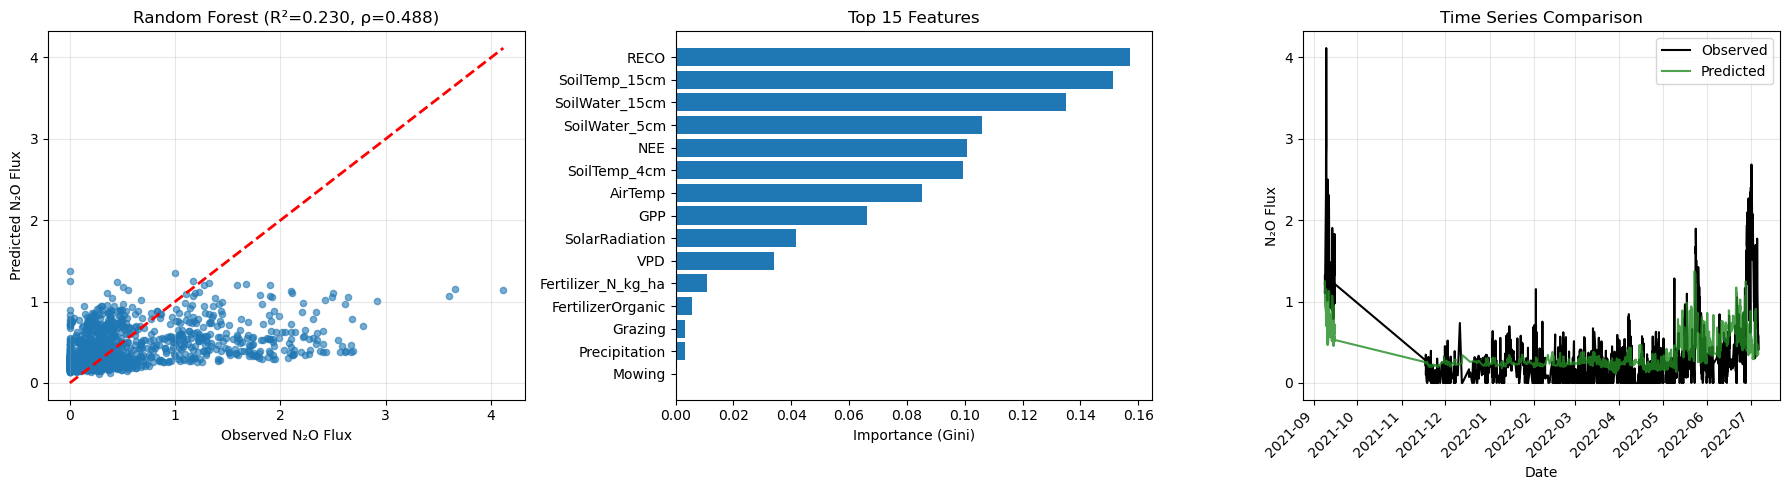

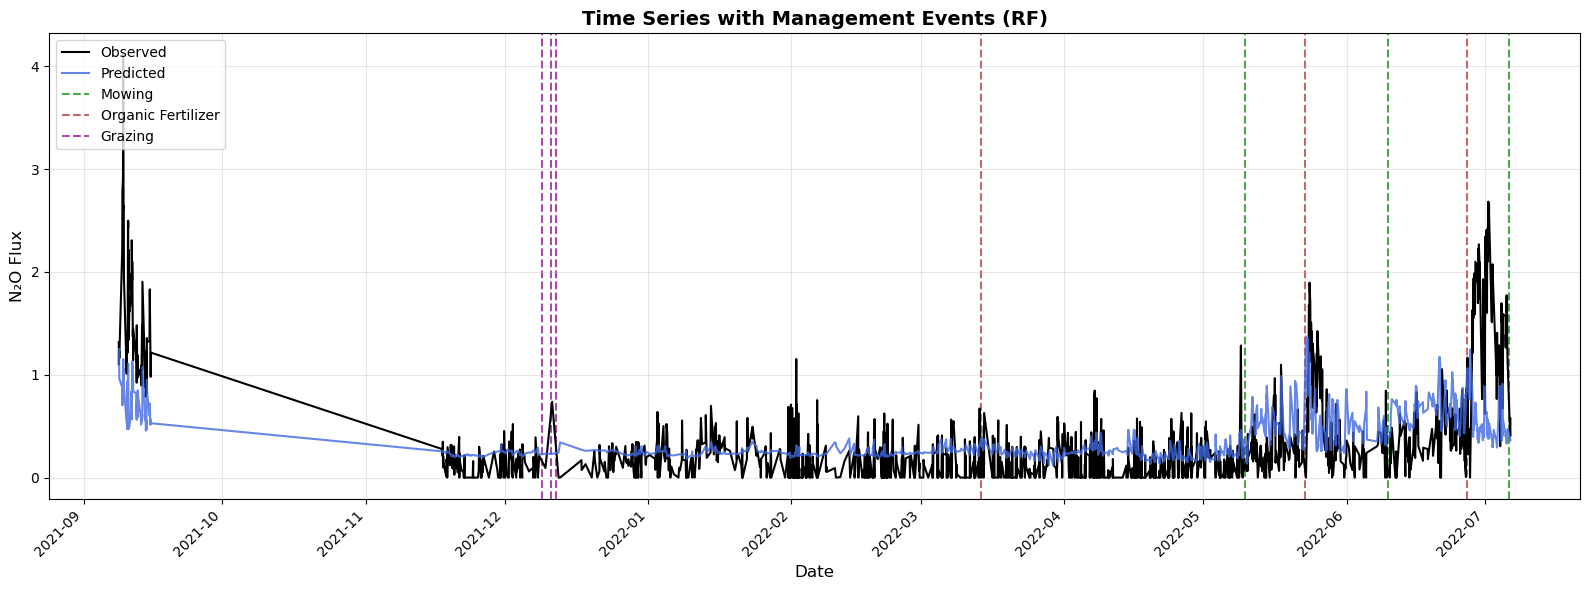

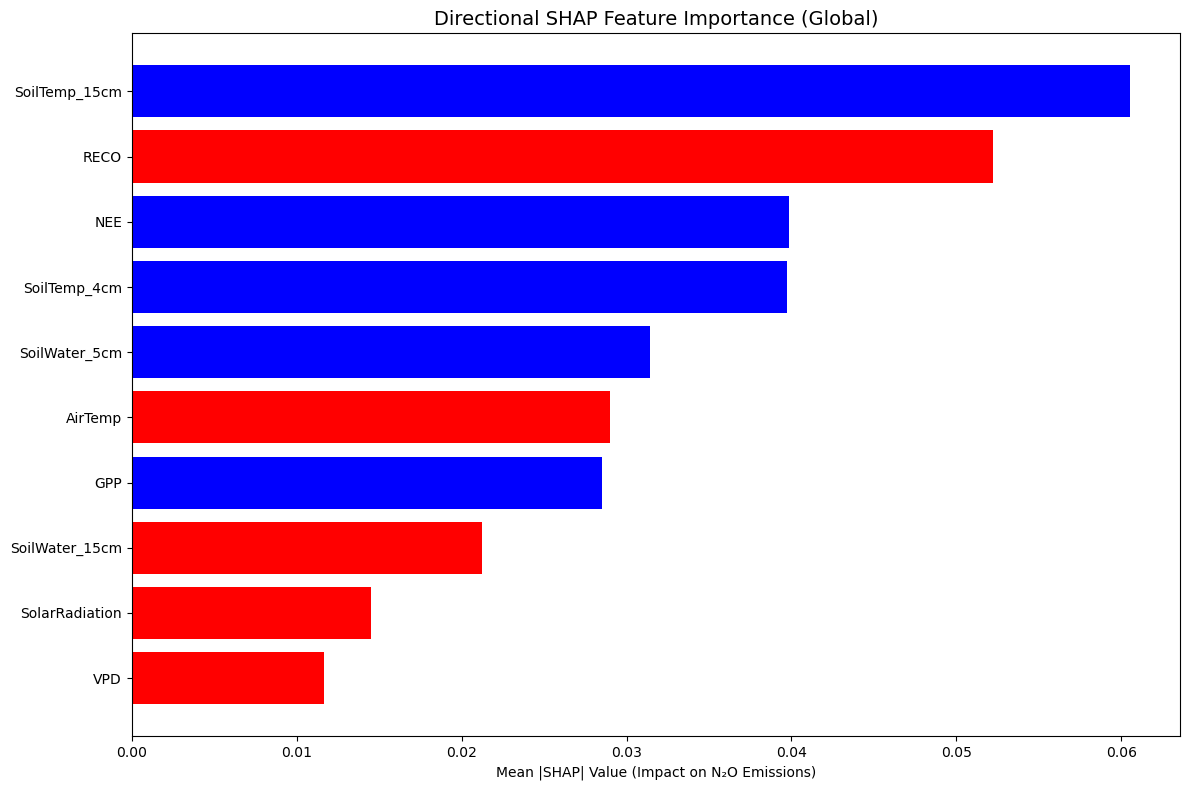

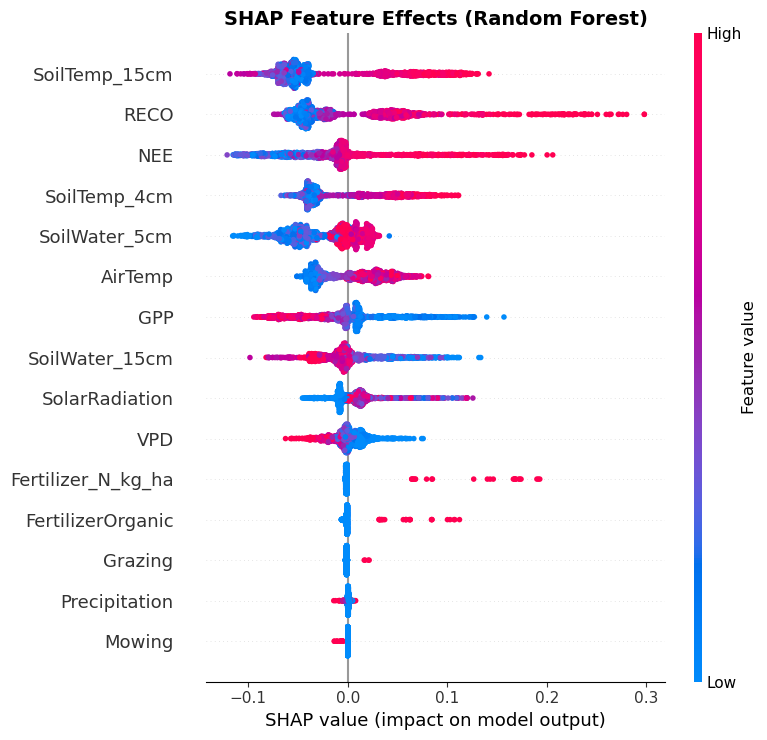


CHAMAU RF - DAILY BASE
Train period: 2014-01-01 00:00:00 → 2021-11-24 00:00:00
Test  period: 2021-11-25 00:00:00 → 2022-07-06 00:00:00
  No data leakage detected

Using custom hyperparameters: {'max_depth': 7, 'max_features': 0.2, 'min_samples_leaf': 11, 'min_samples_split': 10, 'n_estimators': 100}
RF model params: {'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 11, 'max_features': 0.2, 'random_state': 42, 'n_jobs': -1}

Model evaluation:
  R² (linear scale): 0.171
  Spearman ρ:        0.482

Computing SHAP values...


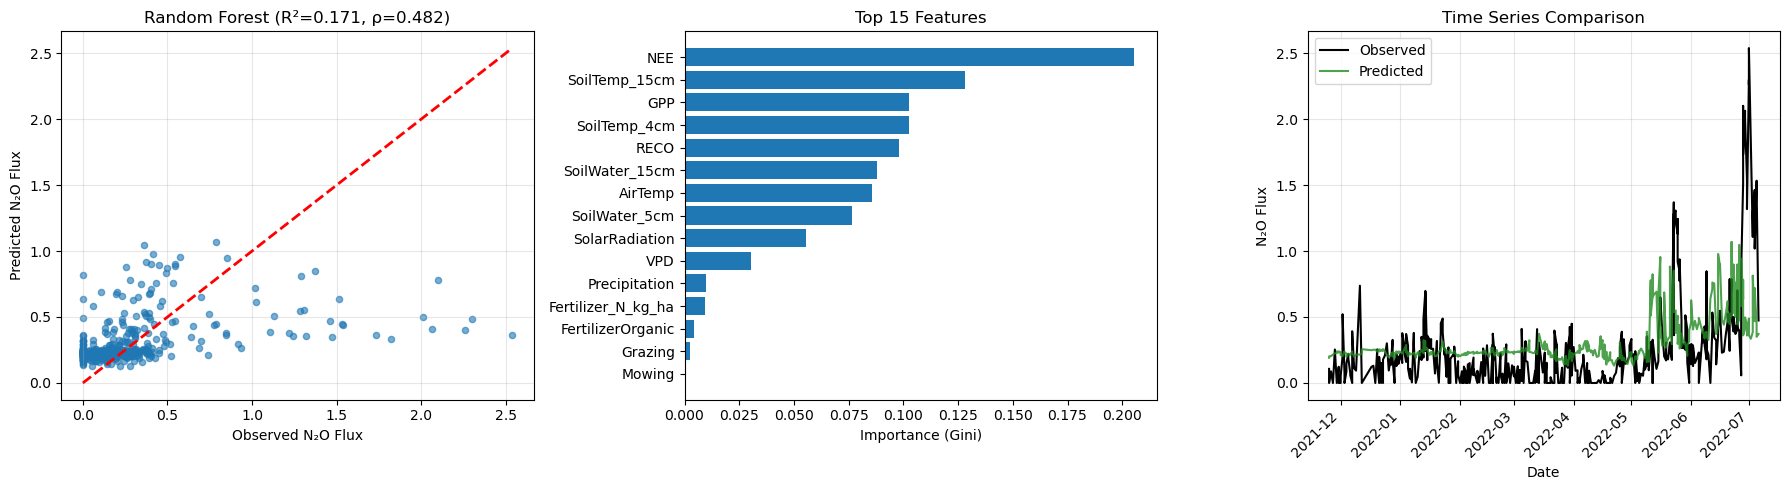

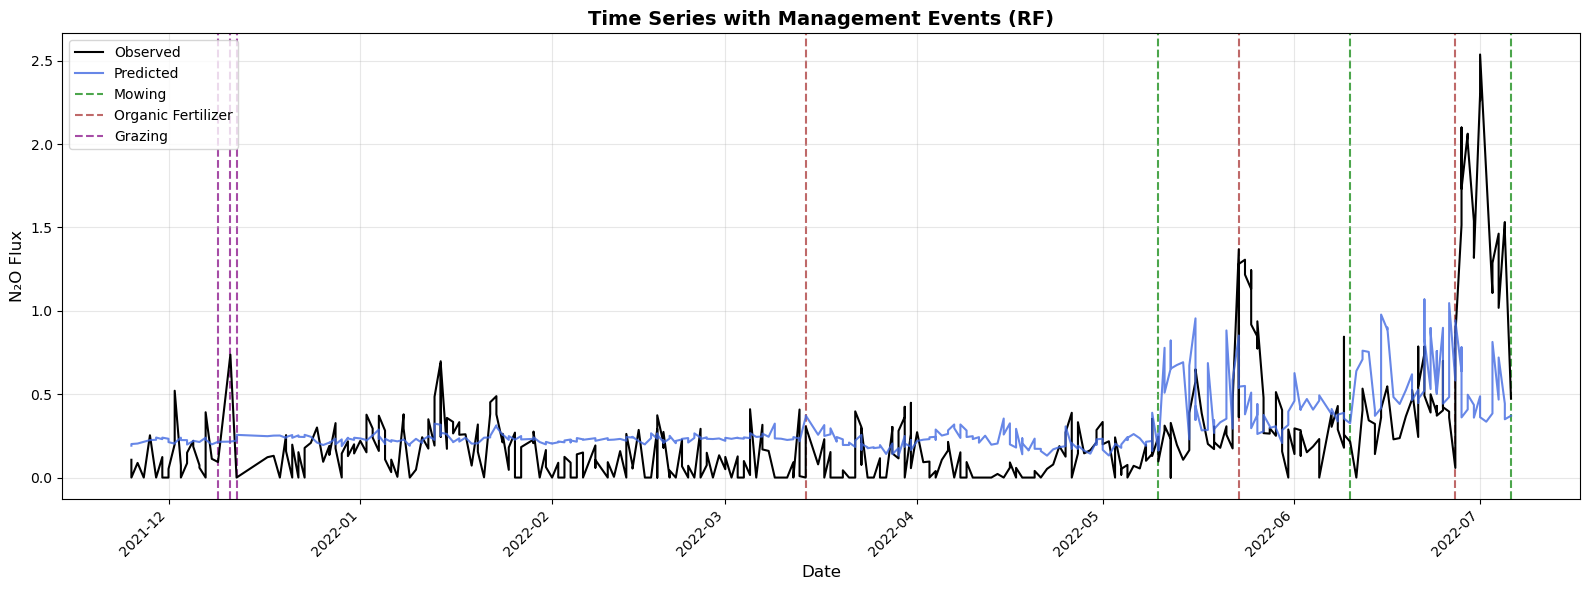

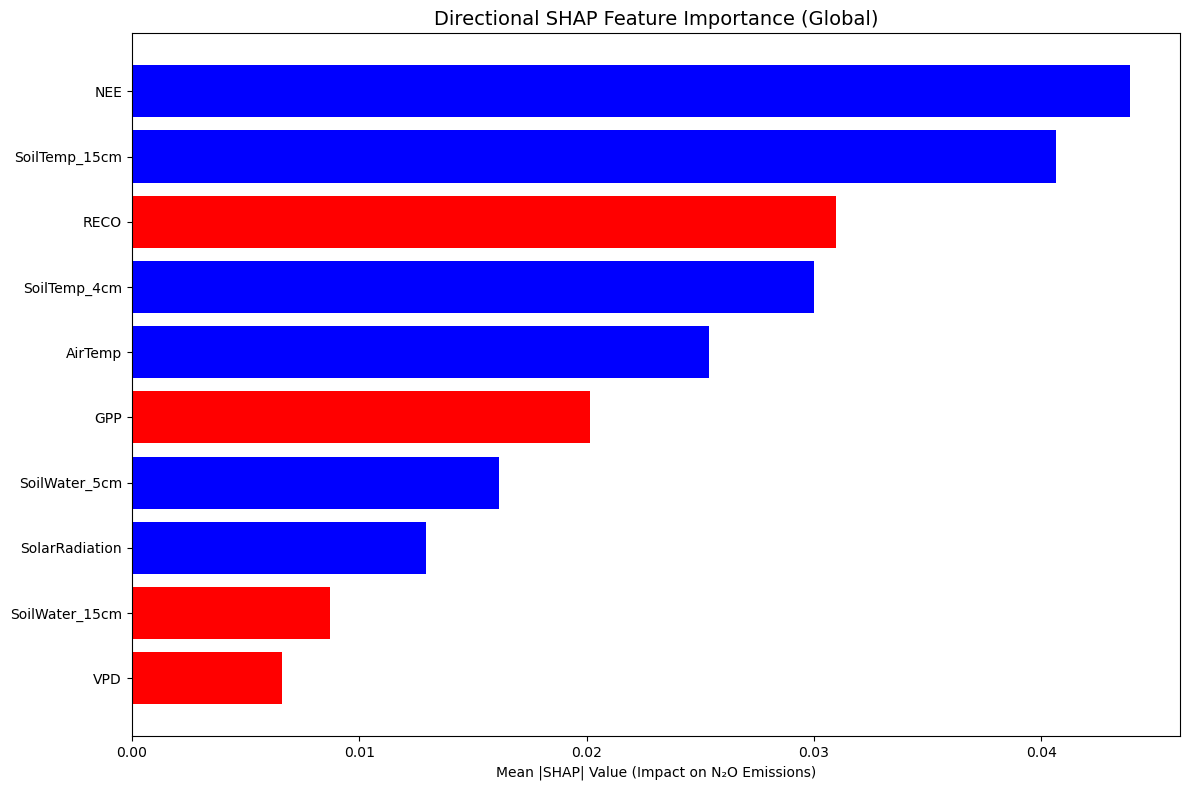

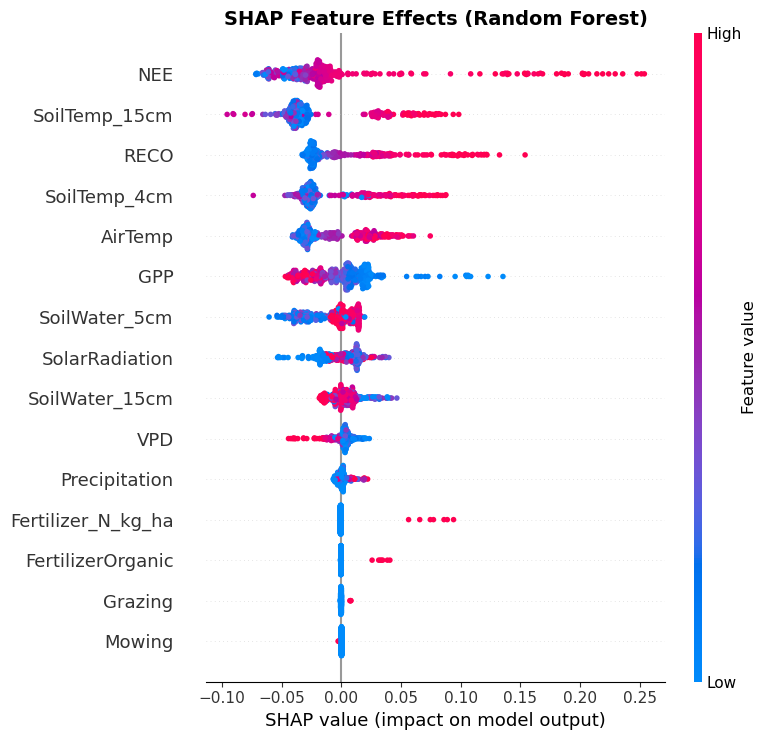


CHAMAU RF - DAILY LAG
Train period: 2014-01-01 00:00:00 → 2021-11-29 00:00:00
Test  period: 2021-11-29 00:00:00 → 2022-07-06 00:00:00
  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 12, 'min_samples_split': 2, 'n_estimators': 1000}
RF model params: {'n_estimators': 1000, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1}

Model evaluation:
  R² (linear scale): 0.371
  Spearman ρ:        0.489

Computing SHAP values...


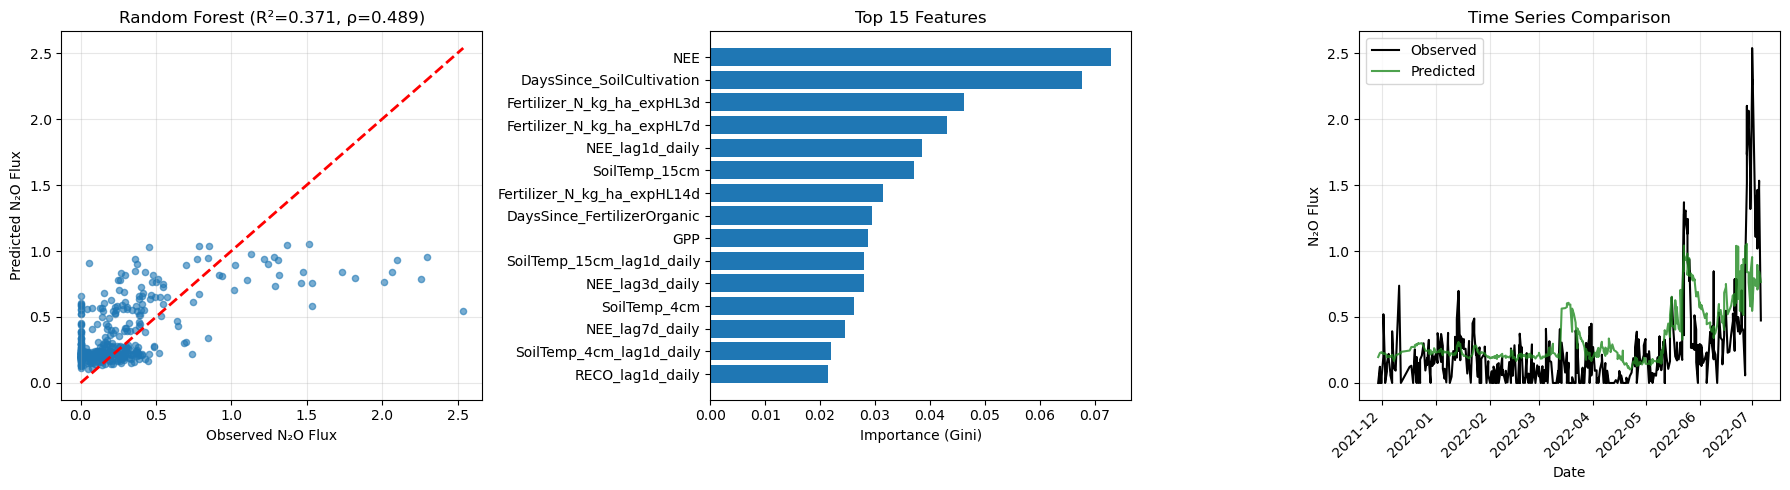

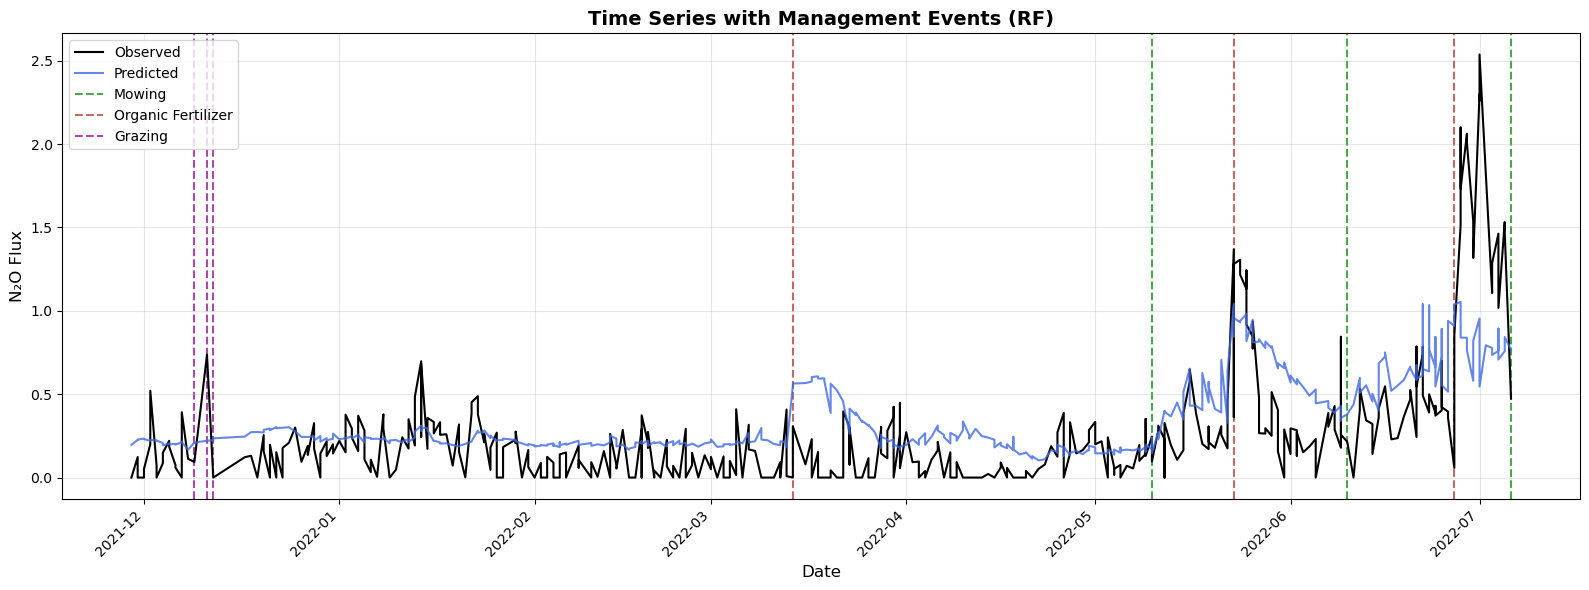

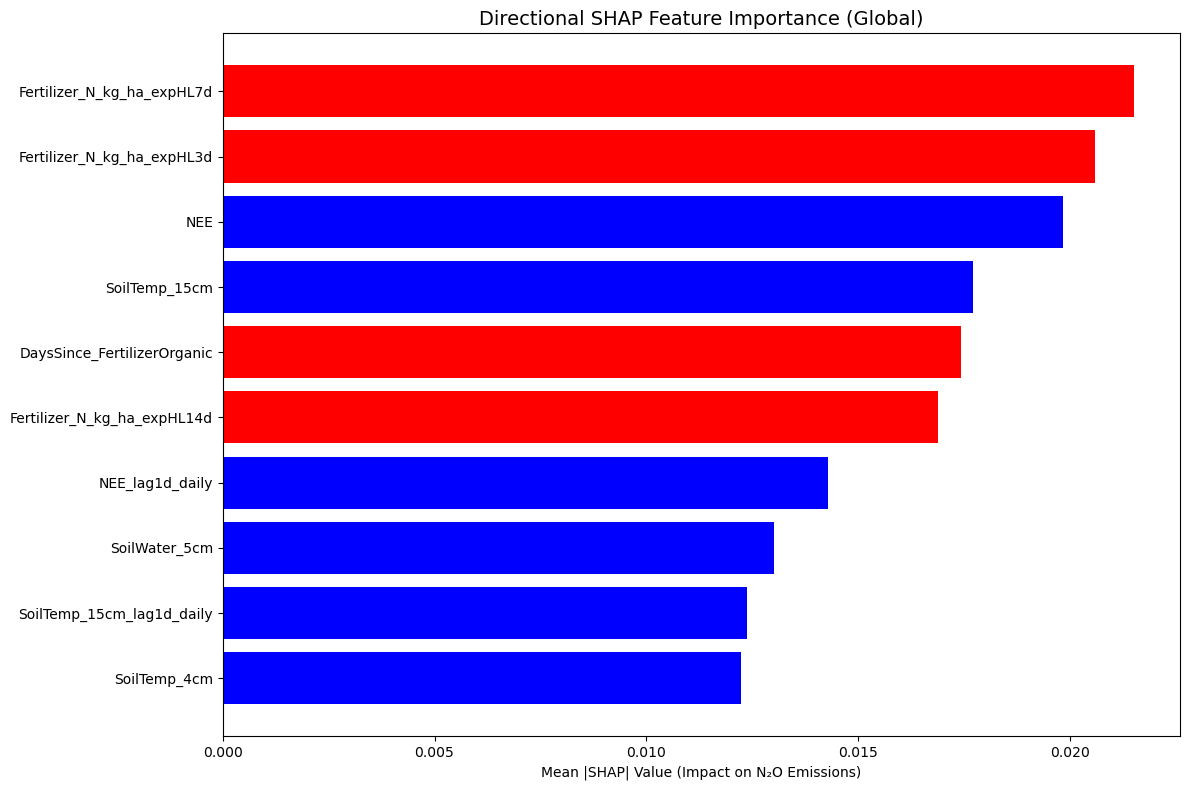

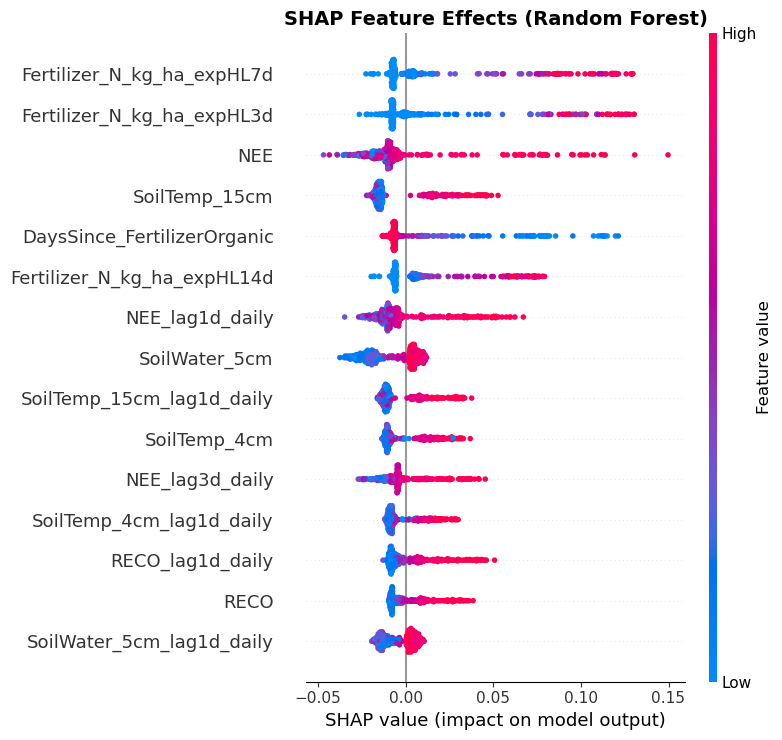


CHAMAU RF - DAILY AUGMENTED
Train period: 2014-01-01 00:00:00 → 2021-11-29 00:00:00
Test  period: 2021-11-29 00:00:00 → 2022-07-06 00:00:00
  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'max_depth': 23, 'max_features': 0.3, 'min_samples_leaf': 15, 'min_samples_split': 20, 'n_estimators': 1000}
RF model params: {'n_estimators': 1000, 'max_depth': 23, 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_features': 0.3, 'random_state': 42, 'n_jobs': -1}

Model evaluation:
  R² (linear scale): 0.334
  Spearman ρ:        0.459

Computing SHAP values...


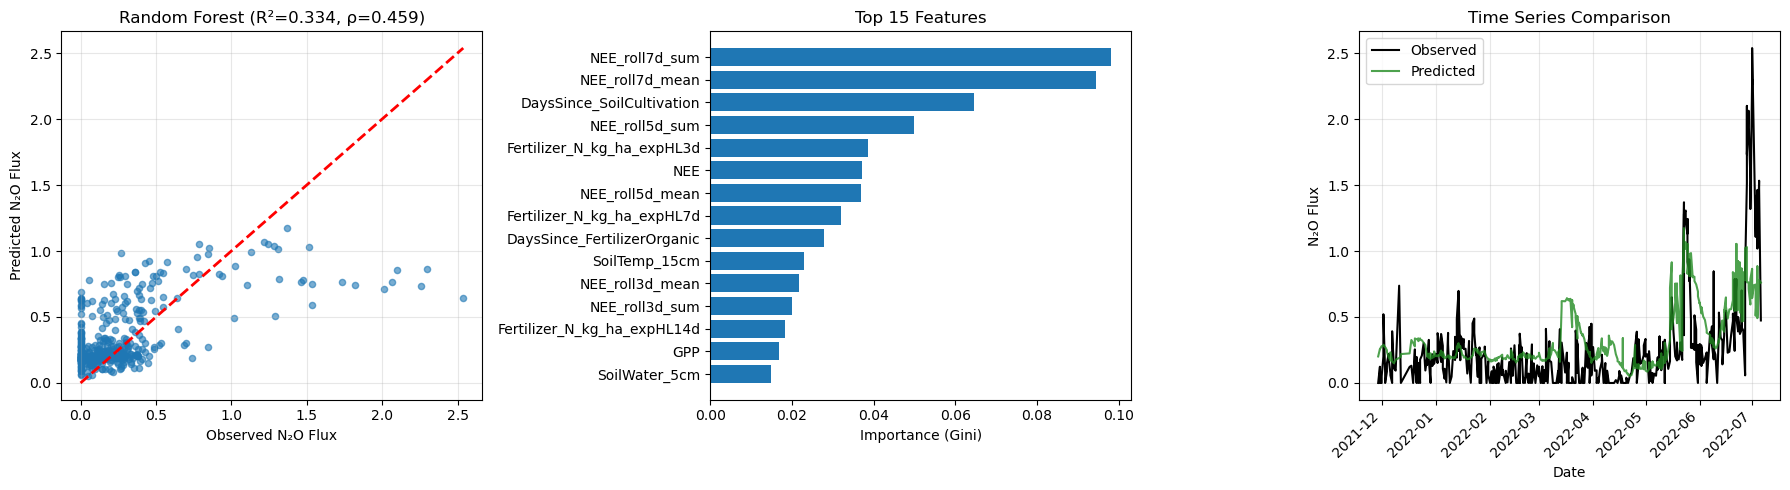

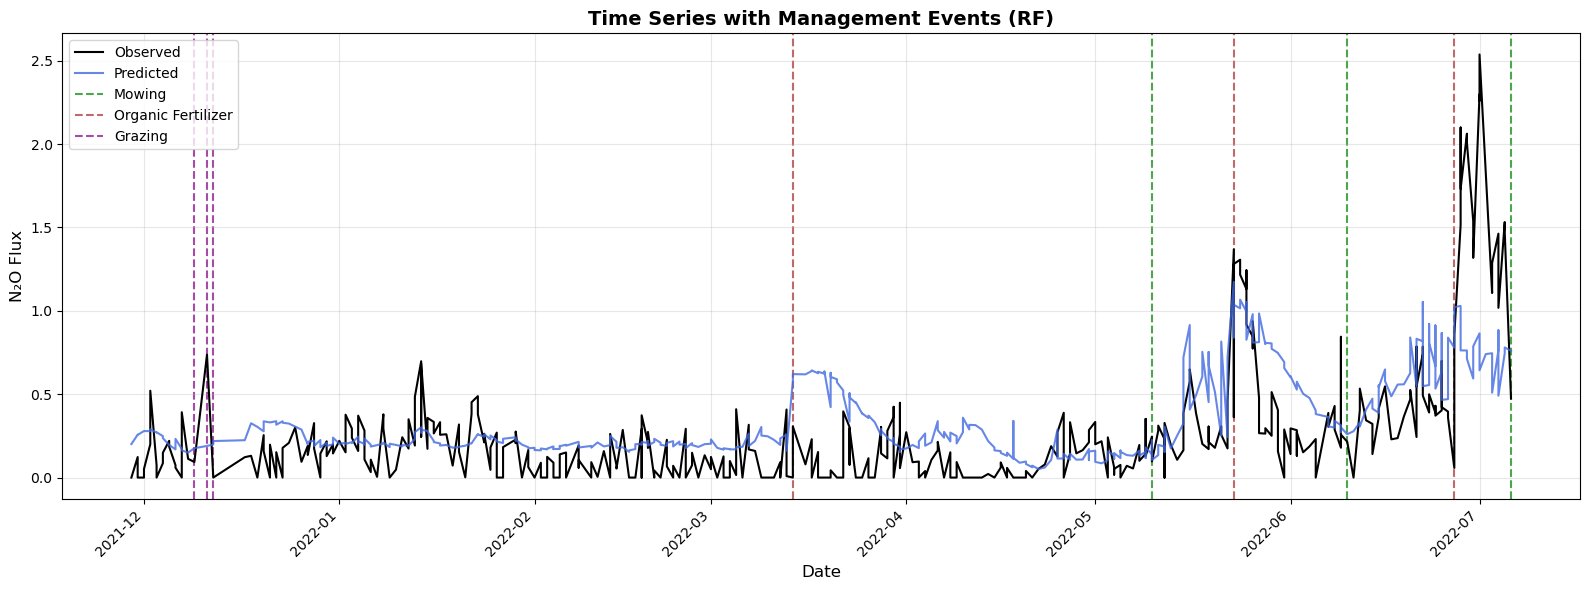

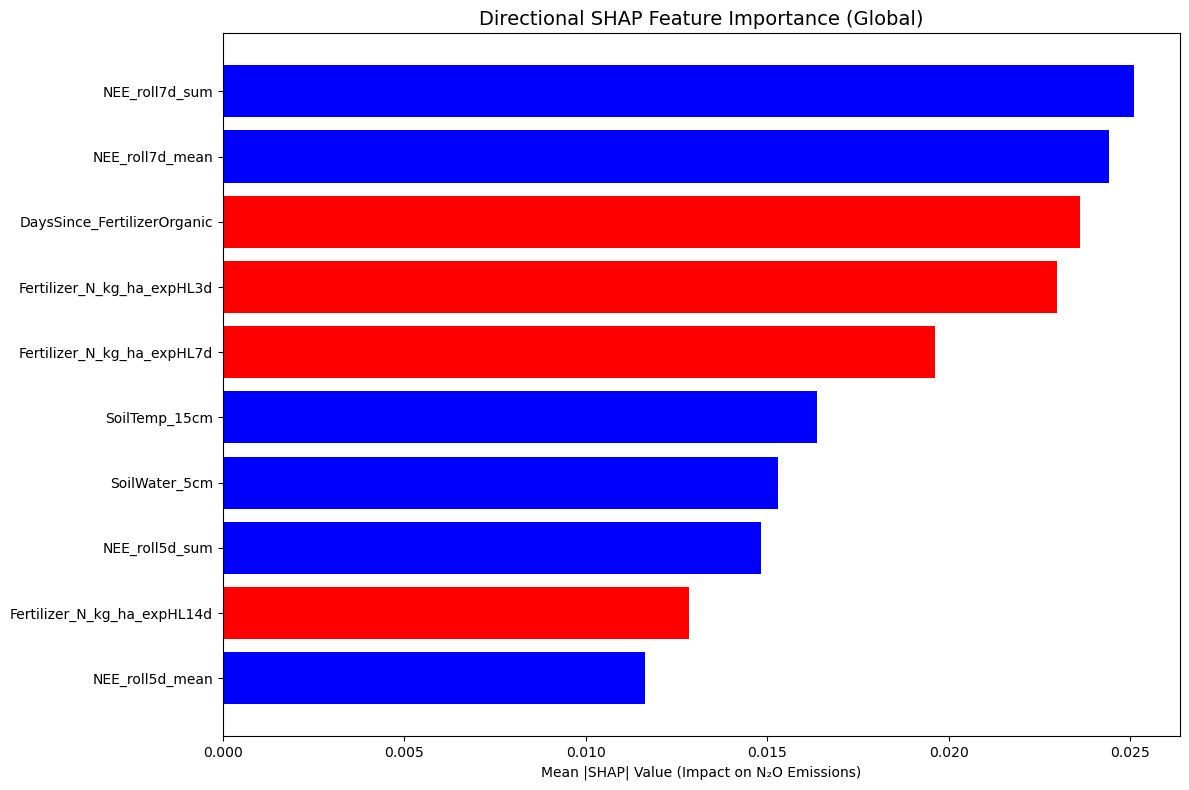

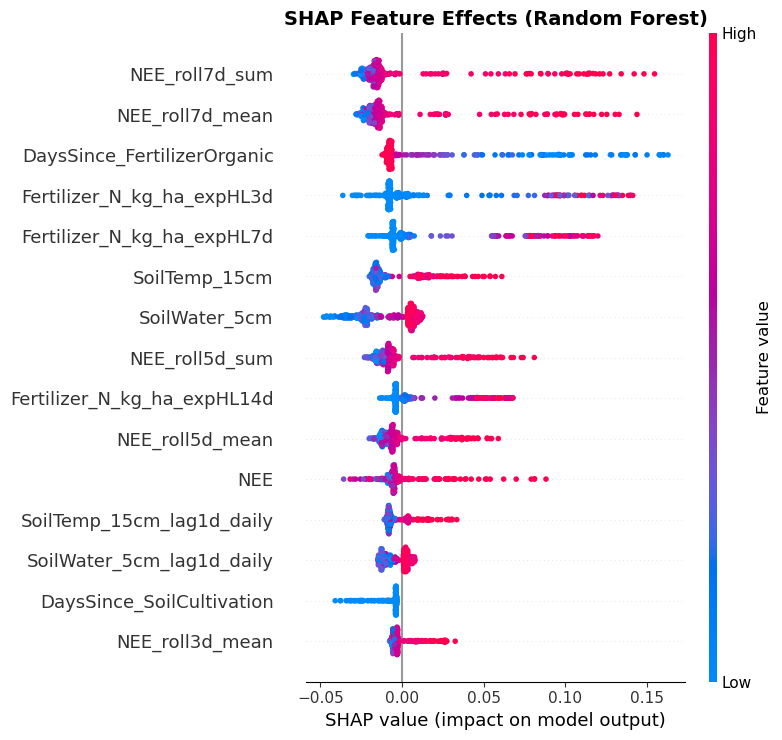

In [13]:
# Random Forest experiments for Chamau
print("="*80)
print("CHAMAU - RANDOM FOREST EXPERIMENTS")
print("="*80)

chamau_rf_experiments = [
    ("Hourly_Base", chamau_lag_df, chamau_base_predictors),
    # ("Hourly_Lag", chamau_lag_df, chamau_lag_predictors),
    # ("Hourly_Augmented", chamau_lag_df, chamau_augmented_predictors),
    ("Daily_Base", chamau_daily_df, chamau_base_predictors),
    ("Daily_Lag", chamau_daily_df, chamau_lag_predictors),
    ("Daily_Augmented", chamau_daily_df, chamau_augmented_predictors),
]

with open("rf_params/Chamau/rf_best_hyperparameters.json", "r") as f:
    chamau_rf_hyperparams = json.load(f)
    
chamau_rf_results = {}
for exp_name, df, predictors in chamau_rf_experiments:
    print("\n" + "="*80)
    print(f"CHAMAU RF - {exp_name.upper().replace('_', ' ')}")
    print("="*80)
    
    chamau_rf_results[exp_name] = train_rf_timeseries_with_shap(
    df=df,
    predictors=predictors,
    target='N2O_Flux_ln',
    test_size=0.1,
    hyperparams=chamau_rf_hyperparams[exp_name]  # Pass the tuned params
    )

OENSINGEN 2021-23 - RANDOM FOREST EXPERIMENTS

OENSINGEN 2021-23 RF - HOURLY BASE
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'max_depth': 50, 'max_features': 0.2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
RF model params: {'n_estimators': 100, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.2, 'random_state': 42, 'n_jobs': -1}

Model evaluation:
  R² (linear scale): 0.034
  Spearman ρ:        0.350

Computing SHAP values...


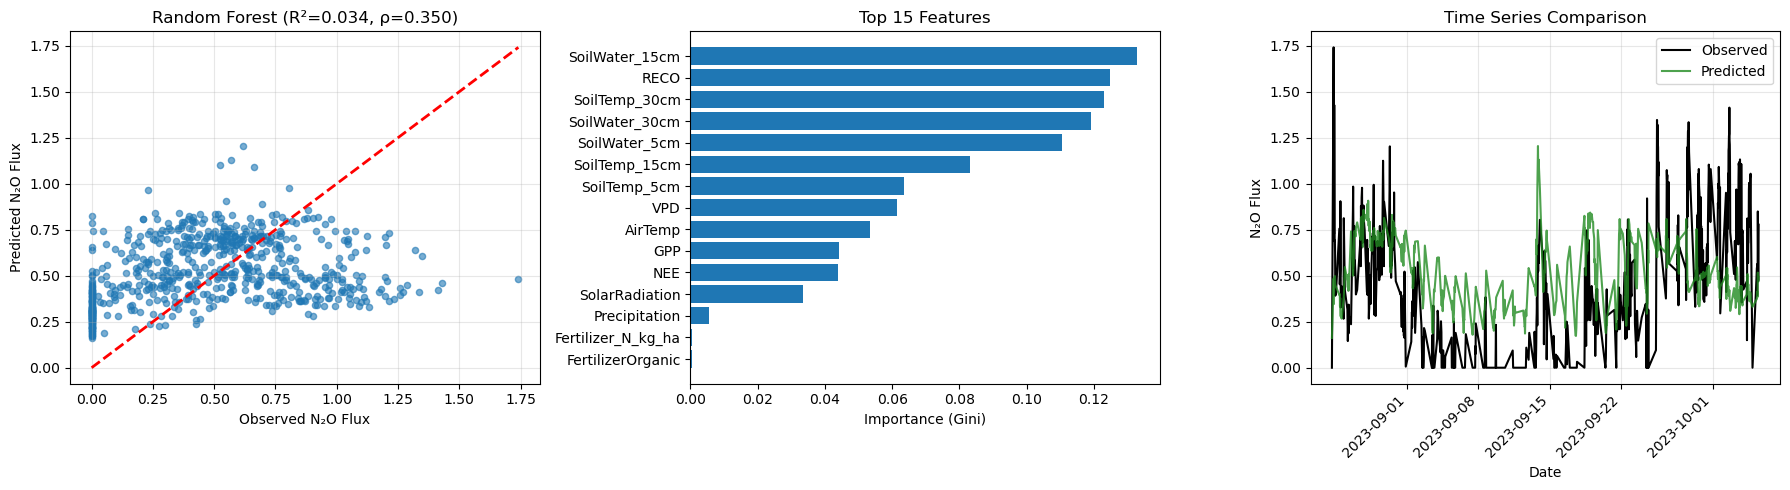

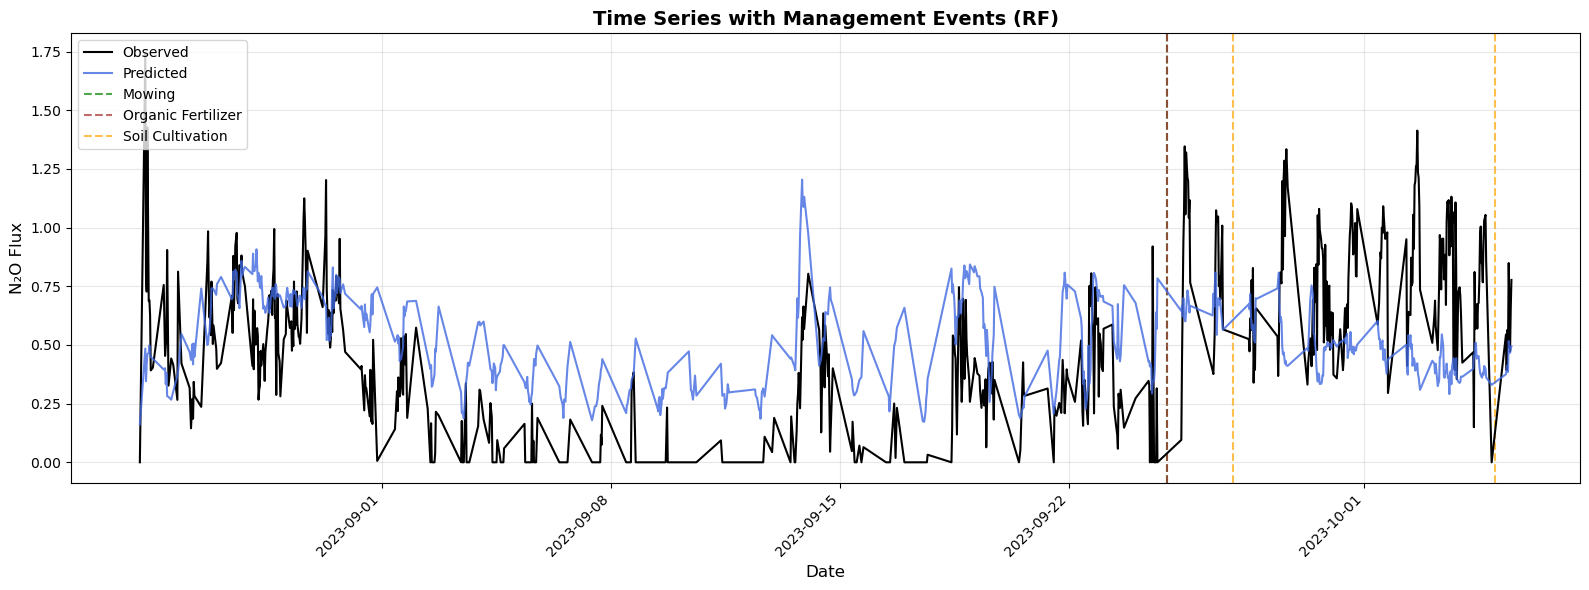

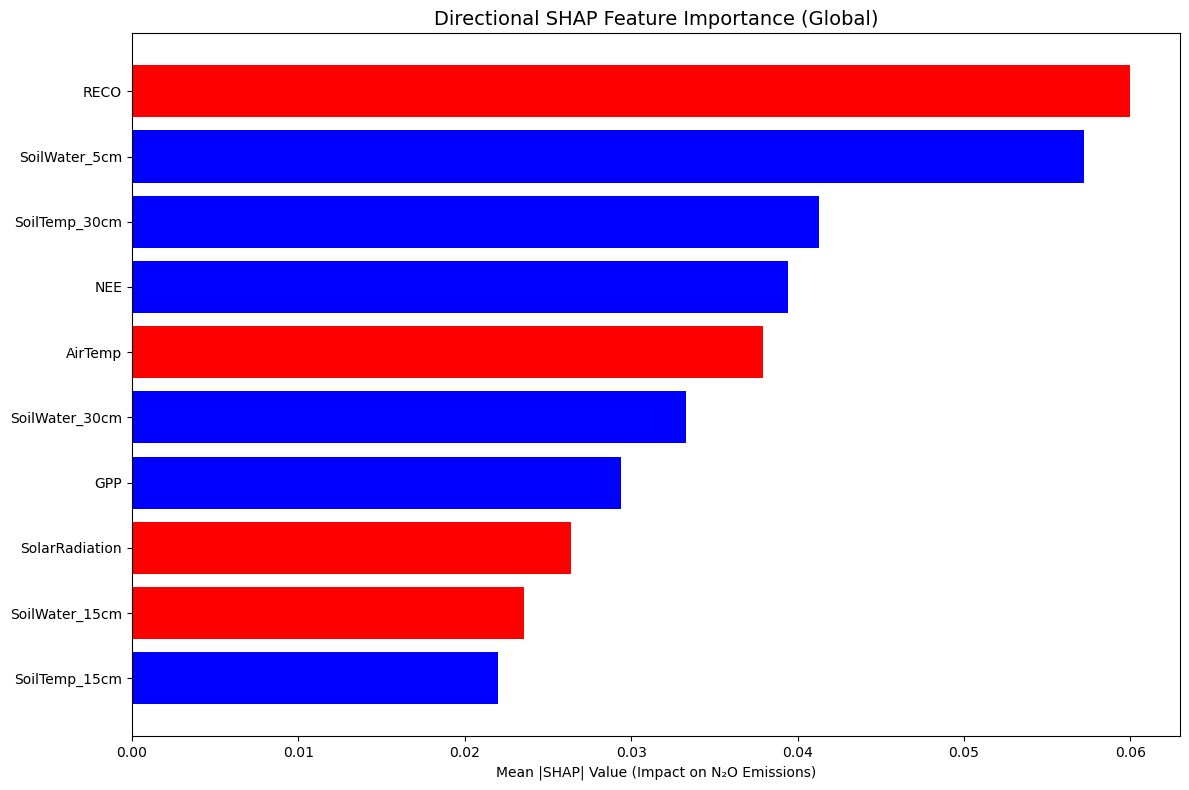

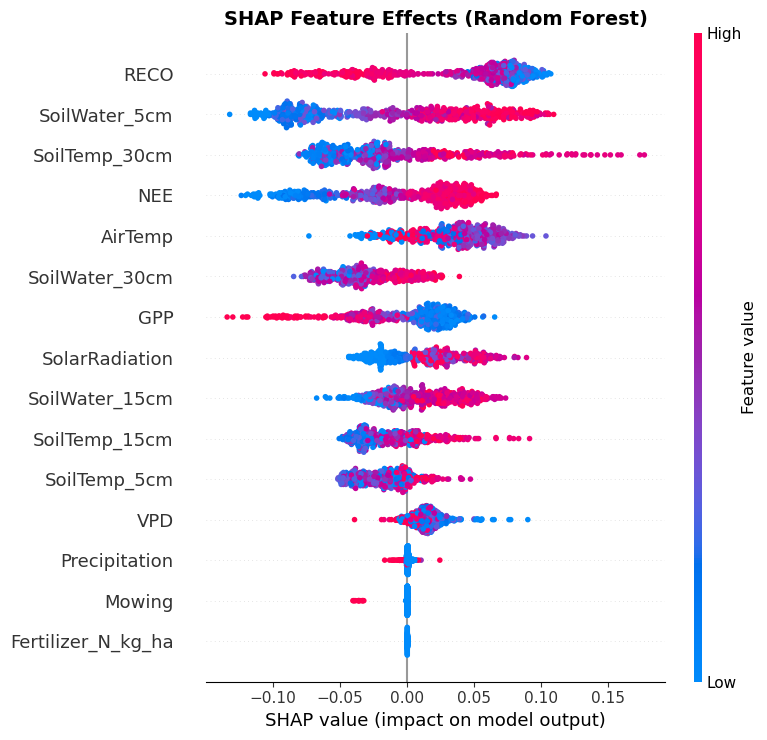


OENSINGEN 2021-23 RF - HOURLY LAG
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00
  DATA LEAKAGE WARNING: 1 dates appear in BOTH train and test!

Using custom hyperparameters: {'max_depth': 37, 'max_features': 0.2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
RF model params: {'n_estimators': 100, 'max_depth': 37, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.2, 'random_state': 42, 'n_jobs': -1}


In [ ]:
# Random Forest experiments for Oensingen 2021-23
print("="*80)
print("OENSINGEN 2021-23 - RANDOM FOREST EXPERIMENTS")
print("="*80)

with open("rf_params/Oensingen_2021-23/rf_best_hyperparameters.json", "r") as f:
    oensingen_rf_hyperparams = json.load(f)

oensingen_rf_experiments = [
    ("Hourly_Base", oensingen_2_lag_df, base_predictors),
    ("Hourly_Lag", oensingen_2_lag_df, hourly_lag_predictors),
    # ("Hourly_Augmented", oensingen_2_lag_df, hourly_augmented_predictors),
    ("Daily_Base", oensingen_2_daily_df, base_predictors),
    ("Daily_Lag", oensingen_2_daily_df, daily_lag_predictors),
    ("Daily_Augmented", oensingen_2_daily_df, daily_augmented_predictors),
]

oensingen_rf_results = {}
for exp_name, df, predictors in oensingen_rf_experiments:
    print("\n" + "="*80)
    print(f"OENSINGEN 2021-23 RF - {exp_name.upper().replace('_', ' ')}")
    print("="*80)
    
    oensingen_rf_results[exp_name] = train_rf_timeseries_with_shap(
        df=df,
        predictors=predictors,
        target='N2O_Flux_ln',
        test_size=0.1,
        hyperparams=oensingen_rf_hyperparams[exp_name]
    )